# Exploratory Data Analysis: ECHR Violation Prediction

## 1. Hypothesis and Research Question

**Research Question:** *Do NLP models predict European Court of Human Rights (ECHR) outcomes on the basis of legally meaningful reasoning, or do they rely on data-provenance issues such as narrative framing and other shortcut signals?*

Specifically, we investigate whether a classifier trained on the **FACTS** section of ECHR judgments learns genuine legal patterns or instead exploits statistical artifacts such as:

- **Spurious keywords:** procedural or formulaic markers such as *represented* that may correlate with outcomes without carrying substantive legal meaning.
- **Document-length bias:** one class may contain systematically shorter or longer FACTS sections.
- **Country-specific patterns:** respondent state may correlate with both outcome and vocabulary, creating a jurisdiction-level shortcut.

**Approach:** We analyze a **retained working sample of 952 FACTS-only judgments** across three respondent states (**Russia, Turkey, and the UK**) after preprocessing and metadata alignment from a larger initial collection. The final analytical sample is therefore **not perfectly balanced by country or outcome**, and all descriptive results in this notebook refer to the retained 952-case dataset.

## 2. Data Applicability

We chose the ECHR dataset for the following reasons:

- **Structured binary labels:** each case has a clear **Violation / Non-Violation** outcome, making the corpus suitable for supervised text classification.
- **Comparative value across jurisdictions:** Russia, Turkey, and the UK provide meaningful cross-country variation in legal context, reporting style, and case mix.
- **Relevance to the hypothesis:** prior literature argues that the **FACTS** sections are drafted *after* the judicial decision, which creates the possibility of post-hoc narrative framing and label leakage.
- **Suitability for exploratory bias analysis:** the dataset contains both textual and metadata-derived signals, allowing us to test whether outcome prediction may depend on non-legal shortcuts.

This notebook is exploratory rather than causal. The aim is to identify potentially informative patterns and possible sources of bias before proceeding to formal modeling.

## 3. Ethical Data Collection Standards

Our data was acquired from the official **HUDOC database** using the `echr-extractor` Python library, which interfaces with the HUDOC API. We adhered to the following standards:

- **Terms-of-service compliance:** we used a public-facing access route and did not bypass access controls.
- **Reasonable request behaviour:** the extraction workflow used controlled request settings rather than aggressive scraping.
- **Sensitivity awareness:** although ECHR judgments are public, they concern human-rights disputes and may encode structural bias; this notebook explicitly examines such risks.
- **Reproducibility:** the data-collection workflow is scriptable, making the pipeline auditable and repeatable.

In [ ]:
# env preparation
# conda create -n echr39 -c conda-forge -y \
#   python=3.9 \
#   numpy=1.23.5 \
#   scipy=1.10.1 \
#   scikit-learn=1.1.3 \
#   pandas matplotlib seaborn nltk jupyter ipykernel

# conda activate echr39
# python -m pip install scattertext shifterator
# python -m ipykernel install --user --name echr39 --display-name "Python (echr39)"

In [2]:
import sklearn, sys
print(sys.version)
print(sklearn.__version__)

#desaired output:
# 3.9.23 | packaged by conda-forge | (main, Jun  4 2025, 18:00:50) 
# [Clang 18.1.8 ]
# 1.1.3

3.9.23 | packaged by conda-forge | (main, Jun  4 2025, 18:00:50) 
[Clang 18.1.8 ]
1.1.3


In [3]:
%matplotlib inline
import pandas as pd
import json
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import re
from collections import Counter
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer

# Advanced NLP Libraries
import nltk
from nltk.text import Text
from nltk.tokenize import word_tokenize

for pkg_path, pkg_name in [
    ('tokenizers/punkt', 'punkt'),
    ('corpora/stopwords', 'stopwords'),
    ('corpora/wordnet', 'wordnet'),
    ('corpora/omw-1.4', 'omw-1.4'),
]:
    try:
        nltk.data.find(pkg_path)
    except LookupError:
        nltk.download(pkg_name)

try:
    import scattertext as st
    HAS_SCATTERTEXT = True
except Exception as e:
    HAS_SCATTERTEXT = False
    st = None
    print(f"scattertext import skipped: {e}")

import shifterator as sh

# Patch shifterator for Python 3.10+ compatibility
import collections
if not hasattr(collections, 'Mapping'):
    import collections.abc
    collections.Mapping = collections.abc.Mapping

# Configure plotting
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

[nltk_data] Downloading package wordnet to /Users/jiejia/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /Users/jiejia/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
/var/folders/0k/nmq27xx94lv9t0qffg3l736c0000gn/T/ipykernel_64009/777302648.py:39: DeprecationWarning: Using or importing the ABCs from 'collections' instead of from 'collections.abc' is deprecated since Python 3.3, and in 3.10 it will stop working
  if not hasattr(collections, 'Mapping'):


## 4. Data Preparation and Inventiveness

Rather than loading a simple flat CSV, we demonstrate inventiveness in data preparation through three techniques:

1. **Section-level text extraction:** Our preprocessing pipeline (`scripts/preprocess_data.py`) uses Regular Expressions to carefully slice each judgment, extracting *only* the "Circumstances of the case" (FACTS) section. The text between the FACTS header and the first occurrence of "THE LAW" / "RELEVANT DOMESTIC LAW" / "RELEVANT LEGAL FRAMEWORK" is kept; everything after is discarded. This is critical for **three reasons**:
   - **"OPERATIVE PROVISIONS"** contains the Court's official verdict — feeding it to the model would provide the target label directly, making prediction trivial.
   - **"THE LAW"** contains the judges' legal reasoning and arguments designed to *justify* the outcome, inherently leaking the decision.
   - By restricting input to the **FACTS** section, we test whether outcomes can be predicted from factual circumstances alone — the core hypothesis of *Legal Realism* (Aletras et al., 2016).
   - **Caveat (Data Provenance):** Even the FACTS section is authored by judges *after* the decision, meaning it may be a retrospective narrative constructed to be consistent with the verdict (Medvedeva & McBride). This is a known limitation.

2. **Feature engineering via Regex:** We parse the `representedby` metadata field to create 3-state version feature. Previous ECHR analysis on *full judgment text* found that the word "represented" appeared in 68% of non-violation cases but only 17% of violation cases (Santosh et al.). Since our pipeline extracts only the FACTS section (excluding THE LAW), this keyword appears far less frequently in our data — itself evidence that our section-level extraction reduces this spurious signal.

3. **Metadata enrichment:** We merge the extracted text with structured metadata (Respondent State, Judgment Year) from the HUDOC database, enabling cross-variable analysis that pure text-only approaches miss.

Below, we load the processed dataset, merge it with raw metadata, and engineer our features. We use `pd.merge()` to combine the processed text DataFrame with the metadata on the `item_id` key, then apply our regex-based lawyer detection function.

In [4]:
# 1. Load Processed Text (FACTS section)
df_text = pd.read_csv('data/processed/processed.csv')

# 2. Load Metadata
df_meta = pd.read_csv('data/raw/metadata.csv')

# 3. Merge based on item_id
df = pd.merge(df_text, df_meta, left_on='item_id', right_on='itemid', how='inner')

# Handle column name conflicts from merge (respondent exists in both)
if 'respondent_x' in df.columns:
    df['respondent'] = df['respondent_x']
    df.drop(columns=[c for c in df.columns if c.endswith('_x') or c.endswith('_y')], errors='ignore', inplace=True)

# 4. Feature Engineering
# Extract Year
df['year'] = pd.to_datetime(df['judgementdate'], dayfirst=True).dt.year

# Inventive Feature: Representation Status using Regex
# We check if 'representedby' is not null, or we could regex the text
def has_lawyer(val):
    if pd.isna(val):
        return False
    val = str(val).lower()
    # If the representation field says 'none', 'self' etc., it might mean no lawyer
    # We use regex to find if it actually contains a lawyer's name or law firm
    if re.search(r'\b(none|n/a)\b', val):
        return False
    return len(val.strip()) > 3

# =========================================================
# Representation feature engineering (3-state version)
# =========================================================

if "representedby" not in df.columns:
    raise ValueError("df is missing the representedby column; cannot build representation features.")

df = df.copy()

def classify_representation(x):
    """
    Returns three states:
    - represented
    - not_represented
    - unknown
    """
    # True missing values
    if pd.isna(x):
        return "unknown"

    s = str(x).strip()
    s_lower = s.lower()

    # Treat as unknown: missing placeholders or noisy placeholders
    unknown_tokens = {
        "", "nan", "none", "null", "n/a", "na", "unknown", "unk", "-", "--"
    }
    if s_lower in unknown_tokens:
        return "unknown"

    # Common expressions treated as not represented
    not_represented_tokens = {
        "no", "no lawyer", "no counsel", "no representative",
        "not represented", "without representation", "self-represented",
        "self represented", "pro se", "in person"
    }
    if s_lower in not_represented_tokens:
        return "not_represented"

    # Very short strings without clear content are usually noisy data; classify as unknown
    if len(s) <= 2:
        return "unknown"

    # All other non-empty and substantive strings are treated as represented
    return "represented"


# 1) Main three-state column
df["representation_status"] = df["representedby"].apply(classify_representation)

# 2) Ordered categories for easier analysis and display
status_order = ["represented", "not_represented", "unknown"]
df["representation_status"] = pd.Categorical(
    df["representation_status"],
    categories=status_order,
    ordered=False
)

# 3) Backward compatibility: keep a binary column (only whether explicitly represented)
#    unknown is not merged into represented
df["has_representation"] = (df["representation_status"] == "represented").astype(int)

# 4) Recommended dummy columns for heatmap / regression
#    Use not_represented as the reference group; keep represented and unknown only
df["repr_represented"] = (df["representation_status"] == "represented").astype(int)
df["repr_unknown"] = (df["representation_status"] == "unknown").astype(int)

# =========================================================
# Quick sanity check
# =========================================================
print("=" * 80)
print("Representation status distribution")
print("=" * 80)
print(df["representation_status"].value_counts(dropna=False))

print("\nProportion:")
print(df["representation_status"].value_counts(normalize=True, dropna=False).round(3))

if "label" in df.columns:
    print("\nCross-tab with label:")
    print(pd.crosstab(df["representation_status"], df["label"], margins=True))

print("\nExample rows:")
display(
    df[["representedby", "representation_status", "has_representation", "repr_represented", "repr_unknown"]]
    .head(15)
)

# Clean up label names for plotting
df['label_name'] = df['label'].map({1: 'Violation', 0: 'Non-Violation'})

print(f"Dataset loaded with {len(df)} records and {len(df.columns)} features.")
print(f"Countries: {df['respondent'].unique()}")
print(f"Label distribution: {df['label_name'].value_counts().to_dict()}")
df[['item_id', 'respondent', 'year', 'has_representation', 'label_name']].head()


Representation status distribution
representation_status
represented        665
unknown            287
not_represented      0
Name: count, dtype: int64

Proportion:
representation_status
represented        0.699
unknown            0.301
not_represented    0.000
Name: proportion, dtype: float64

Cross-tab with label:
label                    0    1  All
representation_status               
represented            305  360  665
unknown                 96  191  287
All                    401  551  952

Example rows:


,representedby,representation_status,has_representation,repr_represented,repr_unknown
0,STICHTING RUSSIAN JUSTICE INITIATIVE,represented,1,1,0
1,FINOGENOV P. A.,represented,1,1,0
2,NaN,unknown,0,0,1
3,KRUTIKOVA Y. ; RACHKOVSKIY M.,represented,1,1,0
4,YADONIST O.,represented,1,1,0
5,SEDLYAR P. V.,represented,1,1,0
6,RYABININA E. ; ZILBERMAN R.,represented,1,1,0
7,MARKIN S. A.,represented,1,1,0
8,NaN,unknown,0,0,1
9,CENTRE OF ASSISTANCE TO INTERNATIONAL PROTECTION,represented,1,1,0


Dataset loaded with 952 records and 38 features.
Countries: ['RUS' 'TUR' 'GBR']
Label distribution: {'Violation': 551, 'Non-Violation': 401}


,item_id,respondent,year,has_representation,label_name
0,001-100029,RUS,2010,1,Violation
1,001-100040,RUS,2010,1,Violation
2,001-100083,RUS,2010,0,Violation
3,001-100099,RUS,2010,1,Violation
4,001-100110,RUS,2010,1,Violation


In [5]:
print(f"Raw Dataset Preview:")
df.head()

Raw Dataset Preview:


,text,label,item_id,violation_articles,nonviolation_articles,year,rulesofcourt,applicability,judgementdate,article,...,originatingbody,itemid,rank,download_label,respondent,representation_status,has_representation,repr_represented,repr_unknown,label_name
0,I. THE CIRCUMSTANCES OF THE CASE4. The applica...,1,001-100029,3;5,NaN,2010,NaN,NaN,22/07/2010 00:00:00,2;3;5;13+2;13,...,4,001-100029,5.000002,violation,RUS,represented,1,1,0,Violation
1,I. THE CIRCUMSTANCES OF THE CASE5. The applica...,1,001-100040,5;6,NaN,2010,NaN,NaN,22/07/2010 00:00:00,5;5-1;6;6-1;6-3-c,...,4,001-100040,6.000002,violation,RUS,represented,1,1,0,Violation
2,I. THE CIRCUMSTANCES OF THE CASE4. The applica...,1,001-100083,6,NaN,2010,NaN,NaN,29/07/2010 00:00:00,6,...,4,001-100083,4.000002,violation,RUS,unknown,0,0,1,Violation
3,I. THE CIRCUMSTANCES OF THE CASE6. The applica...,1,001-100099,3,NaN,2010,NaN,NaN,29/07/2010 00:00:00,3,...,4,001-100099,4.000002,violation,RUS,represented,1,1,0,Violation
4,I. THE CIRCUMSTANCES OF THE CASE6. The applica...,1,001-100110,5,NaN,2010,NaN,NaN,29/07/2010 00:00:00,5;5-1,...,4,001-100110,4.000002,violation,RUS,represented,1,1,0,Violation


## 5. Initial data analysis and implications for data provenance

We now examine the variables in the retained analytical sample. The key fields are:

- **`text`** (string): the extracted **FACTS** section, which is our primary textual feature.
- **`label`** (binary): `1 = Violation`, `0 = Non-Violation`, the target variable.
- **`respondent`** (categorical): the respondent state (`RUS`, `TUR`, `GBR`).
- **`year`** (integer): year of judgment, relevant for temporal-shift analysis.
- **`representation-related metadata`**: an initial binary field (`has_representation`) plus later refined representation-status indicators.
- **`text_length`** (integer): word count of the FACTS section, treated as a potential structural confounder.

We use `value_counts()` and summary statistics to inspect class balance, missingness, and basic feature distributions in the retained 952-case sample.


In [6]:
def compute_text_length_words(series: pd.Series) -> pd.Series:
    """
    Compute the word count for each text entry.
    - empty or missing values are treated as empty strings
    - return int Series
    """
    return series.fillna("").astype(str).apply(lambda x: len(x.split()))

# Class Balance
print("=== Class Distribution ===")
print(df['label_name'].value_counts(normalize=True) * 100)
print("\n")

# Text Length Analysis
df = df.copy()
df["text_length"] = compute_text_length_words(df["text"])
print("=== Text Length (Word Count) Statistics ===")
print(df['text_length'].describe())
print("\n")

# Missing values
print("=== Missing Data in Key Columns ===")
print(df[['text', 'respondent', 'year', 'representedby']].isnull().sum())

=== Class Distribution ===
label_name
Violation        57.878151
Non-Violation    42.121849
Name: proportion, dtype: float64


=== Text Length (Word Count) Statistics ===
count      952.000000
mean      1748.275210
std       1807.274462
min         21.000000
25%        555.000000
50%       1195.000000
75%       2336.750000
max      16403.000000
Name: text_length, dtype: float64


=== Missing Data in Key Columns ===
text               0
respondent         0
year               0
representedby    287
dtype: int64


### Data Cautions

Before proceeding to visualization, we should make several caveats explicit:

* **Post-hoc narrative construction:** the **FACTS** section is not a neutral contemporaneous record; it is written within the judicial process and may reflect outcome-consistent framing.
* **Residual structural differences between classes:** even after restricting the corpus to FACTS-only text, some shortcut signals may remain, including formulaic wording and length differences.
* **Retained-sample composition:** although the broader source collection was larger, the analyses in this notebook use the **952 cases retained after preprocessing and metadata alignment**. The final sample is therefore **not an artificially balanced 200-per-cell design**, so all descriptive statistics below refer to the retained sample only.
* **Metadata incompleteness:** fields such as `representedby` contain missing values, which may reflect incomplete recording rather than a meaningful absence of legal representation.

These caveats matter because apparent predictive signals may arise from sample composition, metadata completeness, or drafting conventions rather than substantive legal reasoning.

### Summary Table by Country
As required by the syllabus, we present a summary table identifying the outcome variable and descriptive statistics broken down by respondent country.

In [7]:
# Summary Table: per country descriptive stats
summary = df.groupby('respondent').agg(
    total_cases=('label', 'count'),
    violations=('label', 'sum'),
    non_violations=('label', lambda x: (x == 0).sum()),
    avg_text_length=('text_length', 'mean'),
    median_text_length=('text_length', 'median'),
    representation_pct=('has_representation', lambda x: f"{x.mean()*100:.1f}%")
).reset_index()
summary.columns = ['Country', 'Total Cases', 'Violations', 'Non-Violations', 
                   'Avg Text Length (words)', 'Median Text Length', 'Has Representation %']
print("=== Summary Table by Respondent Country ===")
summary

=== Summary Table by Respondent Country ===


,Country,Total Cases,Violations,Non-Violations,Avg Text Length (words),Median Text Length,Has Representation %
0,GBR,321,211,110,1938.000000,1413.0,46.1%
1,RUS,408,242,166,1766.808824,1295.0,79.7%
2,TUR,223,98,125,1441.264574,720.0,86.1%


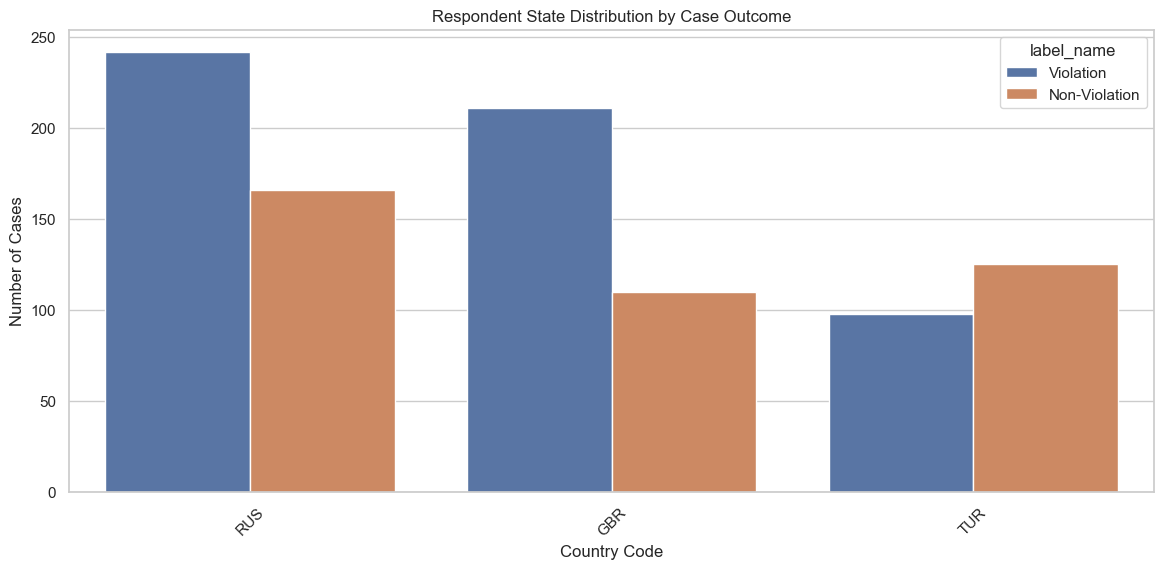

In [39]:
# 2. Respondent State Bias
plt.figure(figsize=(14,6))
country_order = df['respondent'].value_counts().index
sns.countplot(data=df, x='respondent', hue='label_name', order=country_order)
plt.title('Respondent State Distribution by Case Outcome')
plt.xlabel('Country Code')
plt.ylabel('Number of Cases')
plt.xticks(rotation=45)
plt.show()

**Interpretation:** This bar chart reveals geographic distribution across our three target countries (RUS, TUR, GBR). We can see if certain countries have overwhelmingly more Violations vs Non-Violations in the dataset. A predictive model could unfairly penalize a specific country simply by seeing its name in the text (e.g., "The applicant, a citizen of RUS..."), which is a critical finding for ethical modelling.

### 5.1 Article Distribution

Our dataset focuses on four core ECHR articles:
- **Article 3:** Prohibition of torture and inhuman/degrading treatment
- **Article 5:** Right to liberty and security
- **Article 6:** Right to a fair trial
- **Article 8:** Right to respect for private and family life

Understanding the distribution of these articles across countries and outcomes reveals which rights are most frequently litigated in each legal system.

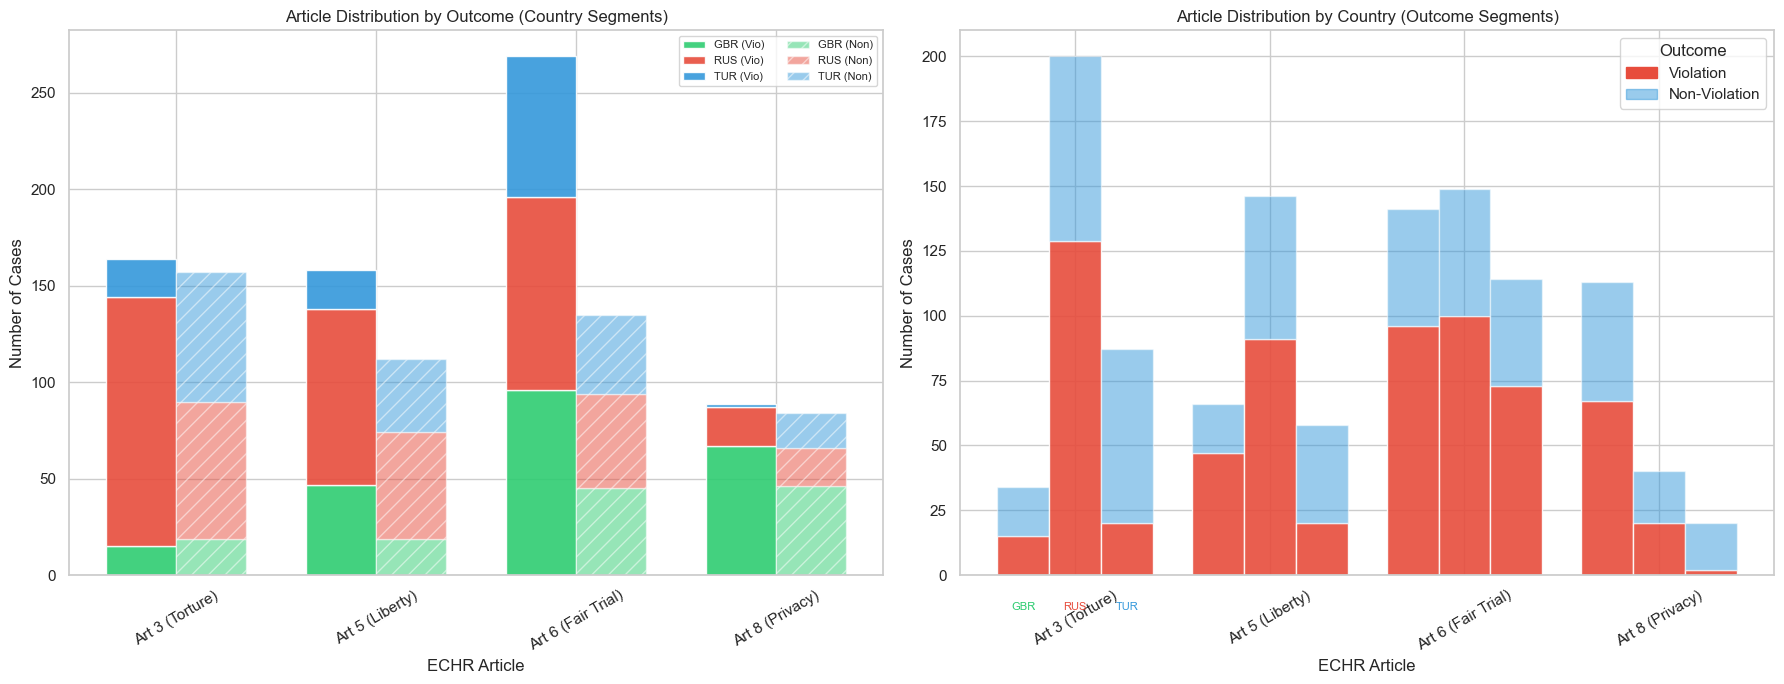

In [40]:
# Parse article information from the violation_articles / nonviolation_articles columns
import re
target_articles = ['3', '5', '6', '8']
article_names = {'3': 'Art 3 (Torture)', '5': 'Art 5 (Liberty)', 
                 '6': 'Art 6 (Fair Trial)', '8': 'Art 8 (Privacy)'}

# Count articles per country per label
article_rows = []
for _, row in df.iterrows():
    country = row['respondent']
    label = row['label_name']
    
    # Check which articles are in the violation/nonviolation fields from metadata
    v_arts = str(row.get('violation_articles', '')).strip()
    nv_arts = str(row.get('nonviolation_articles', '')).strip()
    
    arts_field = v_arts if label == 'Violation' else nv_arts
    if arts_field and arts_field.lower() not in ['nan', '']:
        for art in arts_field.split(';'):
            if art in target_articles:
                article_rows.append({'Country': country, 'Outcome': label, 'Article': article_names.get(art, f'Art {art}')})

if article_rows:
    art_df = pd.DataFrame(article_rows)
    countries = sorted(art_df['Country'].unique())
    outcomes = ['Violation', 'Non-Violation']
    country_colors = {'RUS': '#e74c3c', 'TUR': '#3498db', 'GBR': '#2ecc71'}
    outcome_colors = {'Violation': '#e74c3c', 'Non-Violation': '#3498db'}
    articles_sorted = sorted(art_df['Article'].unique())
    
    fig, axes = plt.subplots(1, 2, figsize=(18, 7))
    
    # Left: Article × Outcome bars, with country segments stacked inside each bar
    x = np.arange(len(articles_sorted))
    width = 0.35
    for i, outcome in enumerate(outcomes):
        bottom = np.zeros(len(articles_sorted))
        for country in countries:
            vals = []
            for art in articles_sorted:
                count = len(art_df[(art_df['Article'] == art) & (art_df['Outcome'] == outcome) & (art_df['Country'] == country)])
                vals.append(count)
            color = country_colors.get(country, '#999')
            hatch = '//' if outcome == 'Non-Violation' else None
            lbl = f"{country} ({outcome[:3]})"
            axes[0].bar(x + (i - 0.5) * width, vals, width, bottom=bottom, 
                       label=lbl, color=color, alpha=0.9 if outcome == 'Violation' else 0.5, hatch=hatch, edgecolor='white')
            bottom += vals
    axes[0].set_title('Article Distribution by Outcome (Country Segments)')
    axes[0].set_xlabel('ECHR Article')
    axes[0].set_ylabel('Number of Cases')
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(articles_sorted, rotation=30)
    axes[0].legend(fontsize=8, ncol=2)
    
    # Right: Article × Country bars, with Violation/Non-Violation segments stacked
    x2 = np.arange(len(articles_sorted))
    bar_w = 0.8 / len(countries)
    for j, country in enumerate(countries):
        bottom = np.zeros(len(articles_sorted))
        for outcome in outcomes:
            vals = []
            for art in articles_sorted:
                count = len(art_df[(art_df['Article'] == art) & (art_df['Country'] == country) & (art_df['Outcome'] == outcome)])
                vals.append(count)
            color = outcome_colors[outcome]
            lbl = f"{outcome}" if j == 0 else None
            axes[1].bar(x2 + (j - len(countries)/2 + 0.5) * bar_w, vals, bar_w, bottom=bottom,
                       label=lbl, color=color, alpha=0.9 if outcome == 'Violation' else 0.5, edgecolor='white')
            bottom += vals
    axes[1].set_title('Article Distribution by Country (Outcome Segments)')
    axes[1].set_xlabel('ECHR Article')
    axes[1].set_ylabel('Number of Cases')
    axes[1].set_xticks(x2)
    axes[1].set_xticklabels(articles_sorted, rotation=30)
    # Custom legend for outcomes only
    from matplotlib.patches import Patch
    axes[1].legend(handles=[Patch(color=outcome_colors['Violation'], label='Violation'),
                            Patch(color=outcome_colors['Non-Violation'], alpha=0.5, label='Non-Violation')],
                  title='Outcome')
    # Add country labels below
    for j, country in enumerate(countries):
        axes[1].annotate(country, xy=(x2[0] + (j - len(countries)/2 + 0.5) * bar_w, 0),
                        xytext=(0, -25), textcoords='offset points', ha='center', fontsize=8, color=country_colors.get(country, '#999'))
    
    plt.tight_layout()
    plt.show()
else:
    print("No article information available in the processed data.")

**Interpretation:** The article distribution reveals which rights are most frequently contested in each country. For example, Russia may have a disproportionate number of Article 3 (torture) violations, while Turkey may be dominated by Article 6 (fair trial) cases. These patterns reflect real-world socio-political dynamics and are important to understand — a model that simply learns "Article 3 mentioned in Russia = violation" would be exploiting a country-specific pattern rather than legal reasoning.

### 5.2 Correlation Matrix

We examine a set of numeric and indicator variables to detect potential confounding structure in the retained sample. The main relationships of interest are:

- **Outcome ↔ text length:** are violation and non-violation cases structurally different in length?
- **Outcome ↔ representation-related indicators:** does recorded representation status behave like a shortcut signal?
- **Outcome ↔ article indicators:** do some invoked articles align more strongly with one class than others?

This heatmap is intended as a **diagnostic overview** rather than a causal analysis. In particular, representation-related variables should be interpreted cautiously because the retained sample does not contain meaningful support for all nominal representation categories.


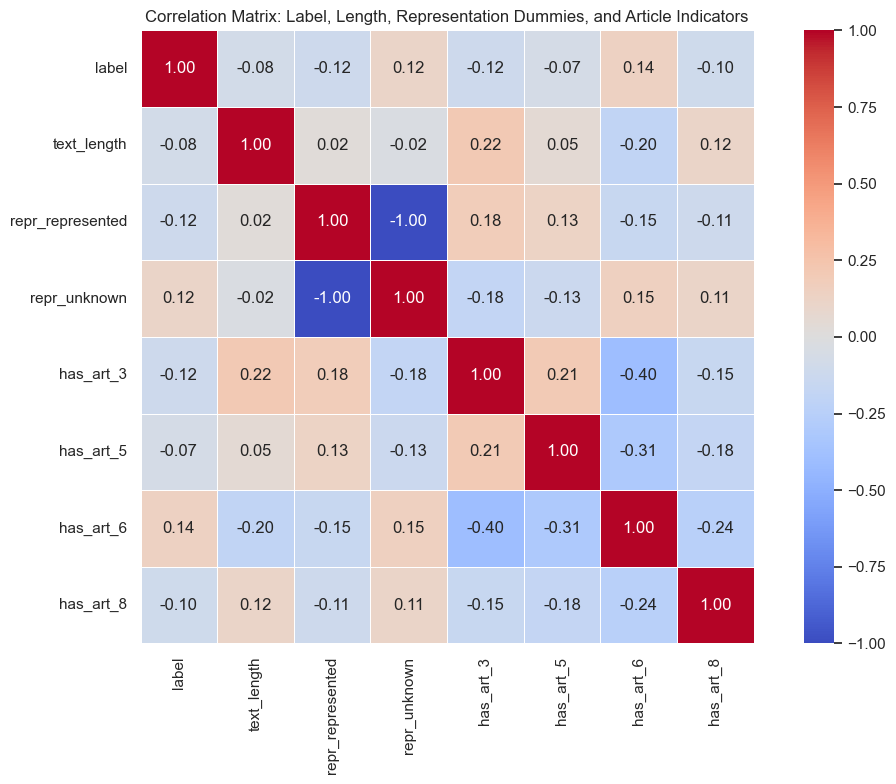

Features used in correlation heatmap
['label', 'text_length', 'repr_represented', 'repr_unknown', 'has_art_3', 'has_art_5', 'has_art_6', 'has_art_8']

Article indicator coverage:
has_art_3  | Art 3 (Torture)        | count=357  | ratio=0.375
has_art_5  | Art 5 (Liberty)        | count=317  | ratio=0.333
has_art_6  | Art 6 (Fair Trial)     | count=436  | ratio=0.458
has_art_8  | Art 8 (Privacy)        | count=193  | ratio=0.203

Representation status distribution:
representation_status
represented        665
unknown            287
not_represented      0
Name: count, dtype: int64

Representation x Label:
label                    0    1  All
representation_status               
represented            305  360  665
unknown                 96  191  287
All                    401  551  952


In [10]:
import re
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# =========================================================
# 1. Basic checks
# =========================================================
required_cols = ["text", "label"]
missing = [c for c in required_cols if c not in df.columns]
if missing:
    raise ValueError(f"df is missing required columns: {missing}")

# If article_map is not defined yet, add a default version here
if "article_map" not in globals():
    article_map = {
        "3": "Art 3 (Torture)",
        "5": "Art 5 (Liberty)",
        "6": "Art 6 (Fair Trial)",
        "8": "Art 8 (Privacy)",
    }

df = df.copy()

# =========================================================
# 2. Standardize text_length: word count (not character count)
# =========================================================
def compute_text_length_words(series: pd.Series) -> pd.Series:
    return series.fillna("").astype(str).apply(lambda x: len(x.split())).astype(int)

df["text_length"] = compute_text_length_words(df["text"])

# =========================================================
# 3. article_mask: avoid matching 3 inside 13 / 23
# =========================================================
def article_mask(series: pd.Series, art_num: str) -> pd.Series:
    pattern = rf'(?:^|[\s,;|/]){re.escape(str(art_num))}(?:$|[\s,;|/])'
    return series.fillna("").str.contains(pattern, regex=True, na=False)

# =========================================================
# 4. Three-state representation feature
#    represented / not_represented / unknown
#    In heatmap, only use repr_represented + repr_unknown
# =========================================================
if "representation_status" not in df.columns:
    if "representedby" not in df.columns:
        print("Warning: representedby column not found in df; skipping representation features.")
    else:
        def classify_representation(x):
            if pd.isna(x):
                return "unknown"

            s = str(x).strip()
            s_lower = s.lower()

            unknown_tokens = {
                "", "nan", "none", "null", "n/a", "na", "unknown", "unk", "-", "--"
            }
            if s_lower in unknown_tokens:
                return "unknown"

            not_represented_tokens = {
                "no", "no lawyer", "no counsel", "no representative",
                "not represented", "without representation",
                "self-represented", "self represented",
                "pro se", "in person"
            }
            if s_lower in not_represented_tokens:
                return "not_represented"

            if len(s) <= 2:
                return "unknown"

            return "represented"

        df["representation_status"] = df["representedby"].apply(classify_representation)
        df["representation_status"] = pd.Categorical(
            df["representation_status"],
            categories=["represented", "not_represented", "unknown"],
            ordered=False
        )

# If representation_status already exists but dummy columns are missing, add them
if "representation_status" in df.columns:
    if "repr_represented" not in df.columns:
        df["repr_represented"] = (df["representation_status"] == "represented").astype(int)
    if "repr_unknown" not in df.columns:
        df["repr_unknown"] = (df["representation_status"] == "unknown").astype(int)

# =========================================================
# 5. Generate article indicator columns
# =========================================================
for art_num, art_name in article_map.items():
    col_name = f"has_art_{art_num}"
    if col_name not in df.columns:
        df[col_name] = (
            article_mask(df.get("violation_articles", pd.Series(index=df.index, dtype=object)), art_num) |
            article_mask(df.get("nonviolation_articles", pd.Series(index=df.index, dtype=object)), art_num)
        ).astype(int)

# =========================================================
# 6. Assemble heatmap features
#    Do not use has_representation anymore
#    Use repr_represented + repr_unknown instead
# =========================================================
feature_cols = ["label", "text_length"]

if "repr_represented" in df.columns:
    feature_cols.append("repr_represented")
if "repr_unknown" in df.columns:
    feature_cols.append("repr_unknown")

feature_cols.extend([f"has_art_{art_num}" for art_num in article_map.keys()])
feature_cols = [c for c in feature_cols if c in df.columns]

corr_df = df[feature_cols].copy()

# =========================================================
# 7. Compute correlation matrix
# =========================================================
corr = corr_df.corr(numeric_only=True)

# =========================================================
# 8. Plot heatmap
# =========================================================
plt.figure(figsize=(11, 8))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5
)
plt.title("Correlation Matrix: Label, Length, Representation Dummies, and Article Indicators")
plt.tight_layout()
plt.show()

# =========================================================
# 9. Auxiliary output
# =========================================================
print("=" * 80)
print("Features used in correlation heatmap")
print("=" * 80)
print(feature_cols)

print("\nArticle indicator coverage:")
for art_num, art_name in article_map.items():
    col_name = f"has_art_{art_num}"
    if col_name in df.columns:
        count_1 = int(df[col_name].sum())
        ratio = df[col_name].mean()
        print(f"{col_name:<10} | {art_name:<22} | count={count_1:<4d} | ratio={ratio:.3f}")

if "representation_status" in df.columns:
    print("\nRepresentation status distribution:")
    print(df["representation_status"].value_counts(dropna=False))

    if "label" in df.columns:
        print("\nRepresentation x Label:")
        print(pd.crosstab(df["representation_status"], df["label"], margins=True))

**Interpretation:**: The word "represented" appears in the FACTS-only corpus at much lower rates than in studies based on full judgments. This supports the claim that section-level extraction reduces an important spurious signal.


### Spurious Correlation: the "represented" Keyword

Prior ECHR work on **full judgment text** reported that the word **"represented"** appeared far more often in one class than the other, making it a plausible shortcut feature.

Because our pipeline keeps only the **FACTS** section and excludes later legal-reasoning sections, we expect this effect to be **substantially weaker** here. The purpose of the analysis below is therefore not to prove that the shortcut disappears entirely, but to test whether a **residual representation-related lexical signal** still remains in the retained FACTS-only sample.


=== Frequency of 'represented' keyword by class (Overall) ===
               Without "represented"  With "represented"
label_name                                              
Non-Violation                   80.0                20.0
Violation                       85.5                14.5

=== GBR ===
               Without "represented"  With "represented"
label_name                                              
Non-Violation                   80.0                20.0
Violation                       75.8                24.2

=== RUS ===
               Without "represented"  With "represented"
label_name                                              
Non-Violation                   77.7                22.3
Violation                       89.3                10.7

=== TUR ===
               Without "represented"  With "represented"
label_name                                              
Non-Violation                   83.2                16.8
Violation                       96.9        

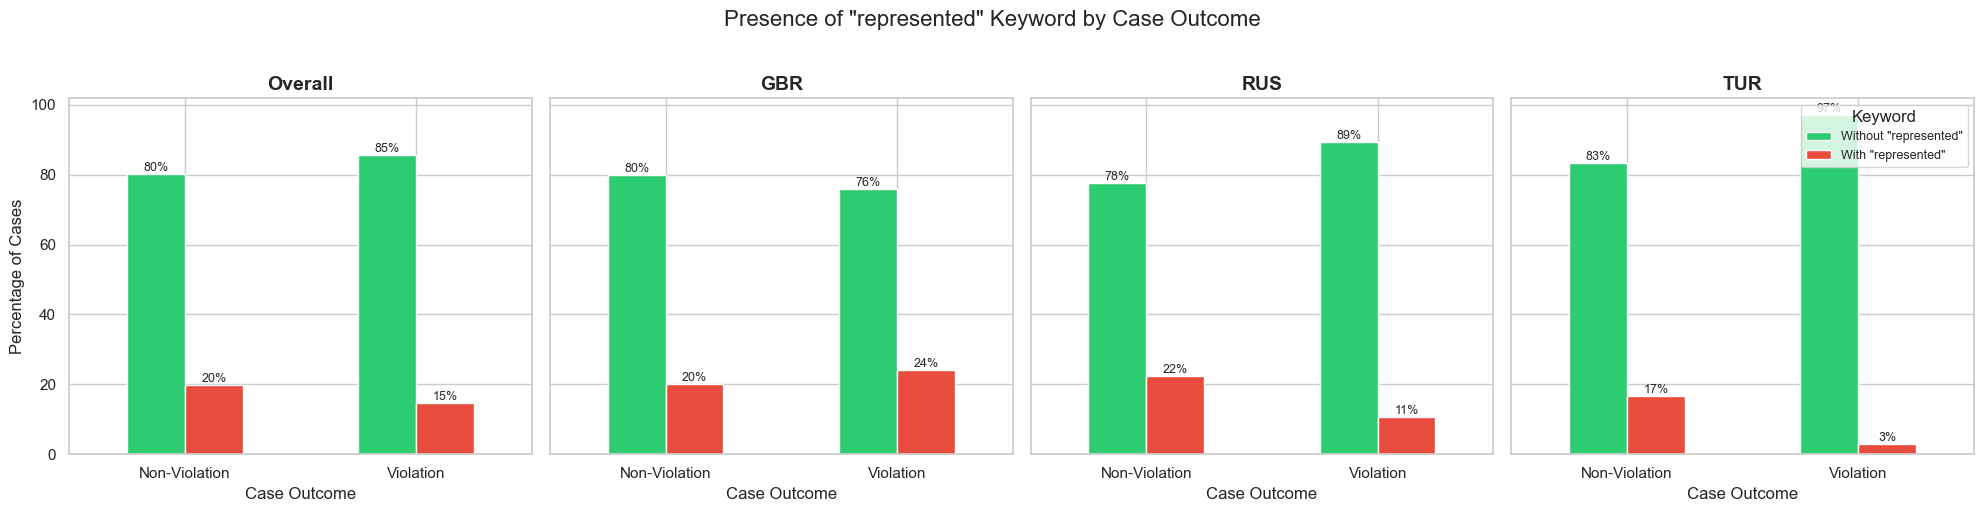

In [11]:
# Check frequency of 'represented' in each class
df['has_represented_word'] = df['text'].str.lower().str.contains(r'\brepresented\b', regex=True, na=False)

represented_stats = pd.crosstab(df['label_name'], df['has_represented_word'], normalize='index') * 100
represented_stats.columns = ['Without "represented"', 'With "represented"']

print("=== Frequency of 'represented' keyword by class (Overall) ===")
print(represented_stats.round(1))
print()

# Combined figure: Overall + Per-Country in one row
countries = sorted(df['respondent'].unique())
fig, axes = plt.subplots(1, 1 + len(countries), figsize=(5 * (1 + len(countries)), 5), sharey=True)

# Subplot 0: Overall
represented_stats.plot(kind='bar', ax=axes[0], color=['#2ecc71', '#e74c3c'], legend=False)
axes[0].set_title('Overall', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Percentage of Cases')
axes[0].set_xlabel('Case Outcome')
axes[0].tick_params(axis='x', rotation=0)
for container in axes[0].containers:
    axes[0].bar_label(container, fmt='%.0f%%', fontsize=9)

# Subplots 1..N: Per-Country
for i, country in enumerate(countries):
    ax = axes[i + 1]
    country_df = df[df['respondent'] == country]
    stats = pd.crosstab(country_df['label_name'], country_df['has_represented_word'], normalize='index') * 100
    stats.columns = ['Without "represented"', 'With "represented"']
    stats.plot(kind='bar', ax=ax, color=['#2ecc71', '#e74c3c'], legend=False)
    ax.set_title(f'{country}', fontsize=14, fontweight='bold')
    ax.set_ylabel('')
    ax.set_xlabel('Case Outcome')
    ax.tick_params(axis='x', rotation=0)
    for container in ax.containers:
        ax.bar_label(container, fmt='%.0f%%', fontsize=9)
    
    # Print stats
    print(f"=== {country} ===")
    print(stats.round(1))
    print()

axes[-1].legend(['Without "represented"', 'With "represented"'], 
               title='Keyword', loc='upper right', fontsize=9)

plt.suptitle('Presence of "represented" Keyword by Case Outcome', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

**Interpretation:** The word **"represented"** appears in the FACTS-only corpus at much lower rates than in studies based on full judgments. This supports the claim that section-level extraction reduces an important spurious signal.

**Concordance analysis**: (see section 6.5, List 4)  on ‘represented’ ascertains it is still used exclusively in its formulaic, registry sense (e.g., "represented by counsel", "represented by mr..."). It’s frequency within our isolated text is just comparatively sparse.

At the same time, the residual pattern is **not perfectly uniform across countries**:

- the overall sample still shows more occurrences in **Non-Violation** than **Violation** cases;
- the same direction is visible in **RUS** and **TUR**;
- **GBR does not follow that direction**, indicating clear country heterogeneity.

The correct conclusion is therefore **not** that this keyword behaves identically in every jurisdiction, but that it remains a **potentially confounded, country-sensitive shortcut feature**. In the modeling phase, it would be appropriate to run an ablation test by removing this token (or broader representation-related wording) and checking whether predictive performance changes materially.


### 5.3 FACTS section text length

**Goal:** examine whether document length behaves as a structural feature that differs by case outcome and could therefore act as a modeling shortcut.


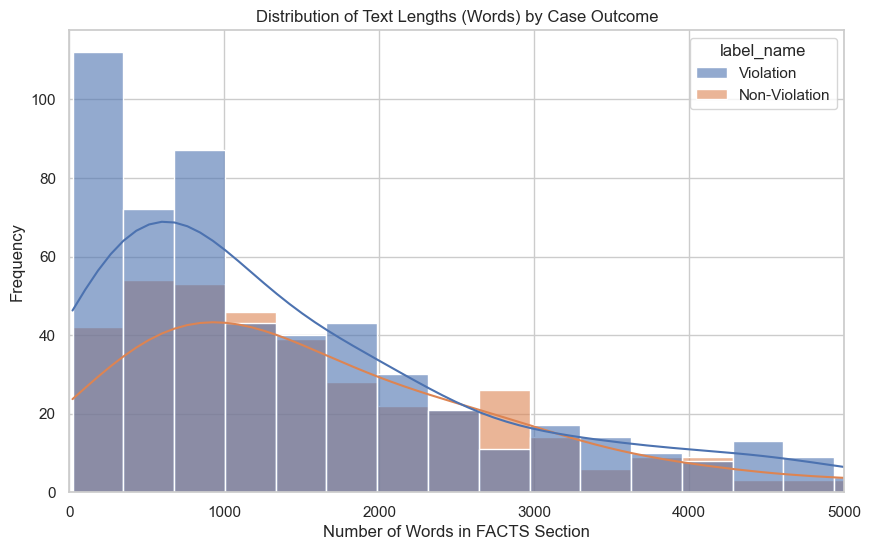

In [12]:
# 1. Distribution of Document Lengths by Class
plt.figure(figsize=(10,6))
sns.histplot(data=df, x='text_length', hue='label_name', bins=50, kde=True, alpha=0.6)
plt.title('Distribution of Text Lengths (Words) by Case Outcome')
plt.xlabel('Number of Words in FACTS Section')
plt.ylabel('Frequency')
plt.xlim(0, 5000) # Cap outliers for better visualization
plt.show()

**Interpretation:** The histogram shows that **Violation cases tend to have shorter FACTS sections** (concentrated at ~200–800 words), while **Non-Violation cases are more spread out with a higher peak** (~800–1200 words). This matches the correlation matrix (r ≈ -0.08: longer text slightly predicts Non-Violation). The pattern likely reflects that Non-Violation (inadmissible) cases often require lengthier factual narratives to establish why the complaint fails, while clear-cut violations may need fewer words to describe the harm. A model could exploit text length alone as a weak predictor without understanding any legal content — this is a bias to track in the modeling phase.

### 5.4 Year Distribution

Year distribution matters because of the **temporal shift** problem: legal doctrine, reporting conventions, and court language evolve over time, so a model trained on earlier judgments may generalize poorly to later ones.

We plot case counts over time to inspect:

- whether the retained sample is **temporally concentrated or skewed**;
- whether some respondent states are over-represented in particular periods;
- whether time may interact with label composition or country composition.

The purpose here is not to claim perfect temporal representativeness, but to assess whether chronological variation is substantial enough to matter for later train/test design.


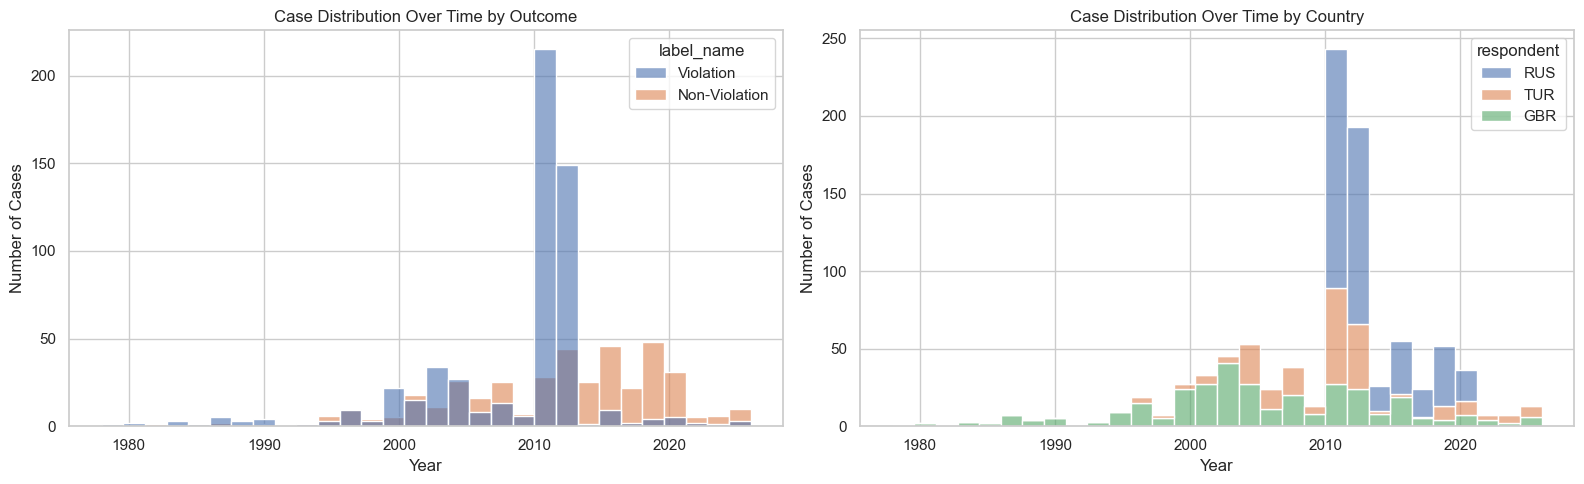

In [13]:
# Year Distribution: Overall histogram by label
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Left: Overall year distribution by label
sns.histplot(data=df, x='year', hue='label_name', bins=30, ax=axes[0], alpha=0.6)
axes[0].set_title('Case Distribution Over Time by Outcome')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Number of Cases')

# Right: Year distribution per country
sns.histplot(data=df, x='year', hue='respondent', bins=30, ax=axes[1], alpha=0.6, multiple='stack')
axes[1].set_title('Case Distribution Over Time by Country')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Number of Cases')

plt.tight_layout()
plt.show()

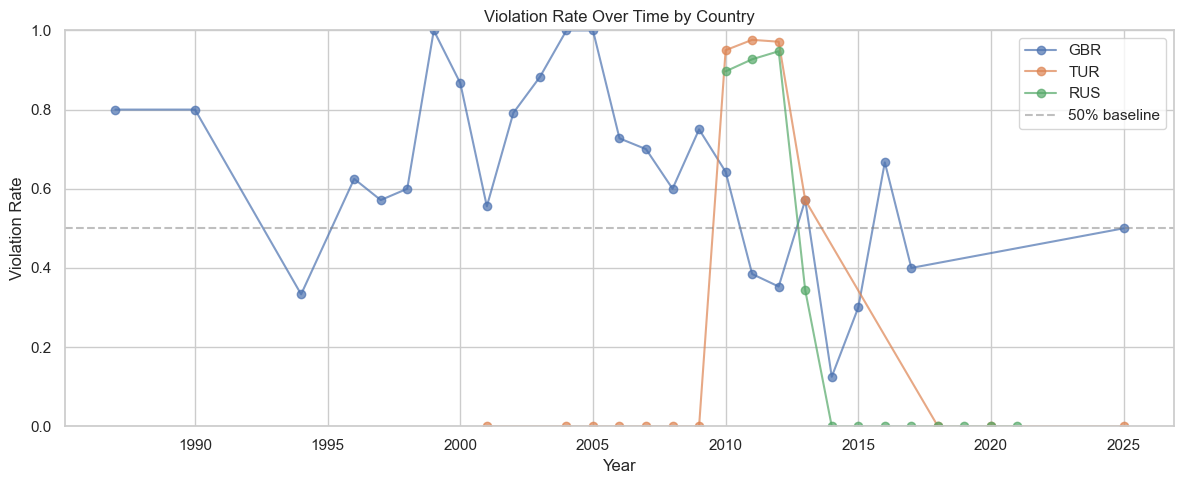

In [14]:
# Temporal Trend: Violation rate per year per country
year_country = df.groupby(['year', 'respondent']).agg(
    total=('label', 'count'),
    violations=('label', 'sum')
).reset_index()
year_country['violation_rate'] = year_country['violations'] / year_country['total']

# Only plot years with enough data (>= 3 cases)
year_country_filtered = year_country[year_country['total'] >= 5]

plt.figure(figsize=(12, 5))
for country in year_country_filtered['respondent'].unique():
    subset = year_country_filtered[year_country_filtered['respondent'] == country]
    plt.plot(subset['year'], subset['violation_rate'], marker='o', label=country, alpha=0.7)

plt.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='50% baseline')
plt.title('Violation Rate Over Time by Country')
plt.xlabel('Year')
plt.ylabel('Violation Rate')
plt.legend()
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

**Interpretation:** 
- The **histogram** shows whether our dataset is concentrated in certain time periods. If most cases come from 2000–2015, we should be cautious about generalizing to post-2019 cases.
- The **violation rate trend** reveals whether certain countries show changing patterns over time (e.g., Russia may have increasing violation rates during certain political periods).
- **Implication for modeling:** The temporal distribution and violation-rate trends suggest that **concept drift** may be a factor — Medvedeva & McBride (2023) reported F1 drops from 0.92 to 0.64–0.68 on future-year evaluations. Whether a chronological or stratified random split yields better generalization is an open question we will investigate in the modeling phase.

## 6. Initial textual analysis with various NLP methods


General functions shared with TF-IDF, CountVectorizer and shifterator.
 - STOPWORDS filtering and lemmatize will not update orignal data, which is df["text"]. 
 - All operations are temp in vecterization

In [15]:
# Shared lexical preprocessing / feature extraction utilities
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords as nltk_stopwords
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from collections import Counter

required_cols = ['text', 'label', 'violation_articles', 'nonviolation_articles']
missing_cols = [c for c in required_cols if c not in df.columns]
if missing_cols:
    raise ValueError(f"df is missing required columns: {missing_cols}")

article_map = {
    '3': 'Art 3 (Torture)',
    '5': 'Art 5 (Liberty)',
    '6': 'Art 6 (Fair Trial)',
    '8': 'Art 8 (Privacy)',
}

wnl = WordNetLemmatizer()

LEGAL_EXTRA_STOPWORDS = {
    "mr", "mrs", "ms", "court", "case"
    # for applicant we don't add it to stopwords; but generic "court" is common and not informative
}
BASE_STOPWORDS = set(nltk_stopwords.words("english"))
ALL_STOPWORDS = BASE_STOPWORDS | LEGAL_EXTRA_STOPWORDS

MANUAL_LEMMA_MAP = {
    "applicants": "applicant",
    "authorities": "authority",
    "proceedings": "proceeding",
    "judges": "judge",
    "lawyers": "lawyer",
    "officers": "officer",
    "children": "child",
    "women": "woman",
    "men": "man",
}

def normalize_token(tok: str) -> str:
    tok = tok.lower().strip()
    tok = MANUAL_LEMMA_MAP.get(tok, tok)

    if not re.search(r"[a-z]", tok):
        return ""

    # Use noun POS for lemmatization to prioritize singular/plural noun normalization (e.g., applicant/applicants)
    tok = wnl.lemmatize(tok, pos="n")
    return tok

def legal_tokenizer(text: str):
    text = str(text).lower()
    tokens = re.findall(r"[a-z']+", text)
    tokens = [normalize_token(t) for t in tokens]
    tokens = [t for t in tokens if t and len(t) > 2 and t not in ALL_STOPWORDS]
    return tokens

def lexicalize_text(text: str) -> str:
    """Join normalized tokens back into a space-separated string for scattertext."""
    return " ".join(legal_tokenizer(text))



def build_vectorizer(vectorizer_cls, ngram_range=(1, 2), min_df=2, max_df=0.9, sublinear_tf=False):
    kwargs = dict(
        tokenizer=legal_tokenizer,
        preprocessor=None,
        token_pattern=None,
        lowercase=False,
        ngram_range=ngram_range,
        min_df=min_df,
        max_df=max_df,
    )
    if vectorizer_cls is TfidfVectorizer:
        kwargs["sublinear_tf"] = sublinear_tf
    return vectorizer_cls(**kwargs)

def get_top_n_tfidf(texts, n=15, ngram_range=(1, 2), min_df=2, max_df=0.9):
    texts = pd.Series(texts).dropna().astype(str)
    if len(texts) == 0:
        return pd.DataFrame(columns=["term", "score"])

    vec = build_vectorizer(
        TfidfVectorizer,
        ngram_range=ngram_range,
        min_df=min_df,
        max_df=max_df,
        sublinear_tf=True
    )
    X = vec.fit_transform(texts)
    scores = np.asarray(X.sum(axis=0)).ravel()
    vocab = np.array(vec.get_feature_names_out())
    order = scores.argsort()[::-1][:n]
    return pd.DataFrame({"term": vocab[order], "score": scores[order]})

def get_top_n_words(texts, n=15, ngram_range=(1, 1), min_df=3, max_df=0.9):
    texts = pd.Series(texts).dropna().astype(str)
    if len(texts) == 0:
        return pd.DataFrame(columns=["term", "count"])

    vec = build_vectorizer(
        CountVectorizer,
        ngram_range=ngram_range,
        min_df=min_df,
        max_df=max_df
    )
    X = vec.fit_transform(texts)
    counts = np.asarray(X.sum(axis=0)).ravel()
    vocab = np.array(vec.get_feature_names_out())
    order = counts.argsort()[::-1][:n]
    return pd.DataFrame({"term": vocab[order], "count": counts[order]})

def get_counts(texts):
    counts = Counter()
    for text in pd.Series(texts).dropna().astype(str):
        counts.update(legal_tokenizer(text))
    return dict(counts)

if "text_lexical" not in df.columns:
    df["text_lexical"] = df["text"].fillna("").astype(str).apply(lambda x: " ".join(legal_tokenizer(x)))

print("Lexical pipeline ready.")
print("Example normalization:", legal_tokenizer("The applicants and police officers were in proceedings before the courts.")[:12])

Lexical pipeline ready.
Example normalization: ['applicant', 'police', 'officer', 'proceeding']


Suggested domain stopword candidates so that could add words manually and accordingly afterwards

In [16]:
from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd
import numpy as np

TOP_K = 30
MIN_DF_RATIO = 0.10   # Must appear in at least 10% of documents
MAX_CANDIDATES = 40

def get_top_n_words_df(texts, n=30, ngram_range=(1, 1), min_df=3, max_df=0.95):
    texts = pd.Series(texts).dropna().astype(str)
    if len(texts) == 0:
        return pd.DataFrame(columns=["term", "count"])

    vec = CountVectorizer(
        tokenizer=legal_tokenizer,
        preprocessor=None,
        token_pattern=None,
        lowercase=False,
        ngram_range=ngram_range,
        min_df=min_df,
        max_df=max_df
    )
    X = vec.fit_transform(texts)
    counts = np.asarray(X.sum(axis=0)).ravel()
    vocab = np.array(vec.get_feature_names_out())
    order = counts.argsort()[::-1][:n]

    return pd.DataFrame({
        "term": vocab[order],
        "count": counts[order]
    })

def get_document_frequency(texts, ngram_range=(1, 1), min_df=1, max_df=1.0):
    texts = pd.Series(texts).dropna().astype(str)
    vec = CountVectorizer(
        tokenizer=legal_tokenizer,
        preprocessor=None,
        token_pattern=None,
        lowercase=False,
        binary=True,
        ngram_range=ngram_range,
        min_df=min_df,
        max_df=max_df
    )
    X = vec.fit_transform(texts)
    dfreq = np.asarray(X.sum(axis=0)).ravel()
    vocab = np.array(vec.get_feature_names_out())

    out = pd.DataFrame({
        "term": vocab,
        "doc_freq": dfreq,
        "doc_freq_ratio": dfreq / len(texts)
    }).sort_values(["doc_freq", "term"], ascending=[False, True])

    return out

# ===== 1) overall / per-label top terms =====
overall_top = get_top_n_words_df(df["text"], n=TOP_K, ngram_range=(1,1), min_df=3)
viol_top = get_top_n_words_df(df.loc[df["label"] == 1, "text"], n=TOP_K, ngram_range=(1,1), min_df=3)
nonviol_top = get_top_n_words_df(df.loc[df["label"] == 0, "text"], n=TOP_K, ngram_range=(1,1), min_df=3)

candidate_terms = (
    set(overall_top["term"]) |
    set(viol_top["term"]) |
    set(nonviol_top["term"])
)

# ===== 2) document frequency =====
df_stats = get_document_frequency(df["text"], ngram_range=(1,1), min_df=1, max_df=1.0)

candidates = df_stats[df_stats["term"].isin(candidate_terms)].copy()
candidates = candidates[candidates["doc_freq_ratio"] >= MIN_DF_RATIO].copy()

# Mark which top lists this term appears in
candidates["in_overall_top30"] = candidates["term"].isin(set(overall_top["term"]))
candidates["in_violation_top30"] = candidates["term"].isin(set(viol_top["term"]))
candidates["in_nonviolation_top30"] = candidates["term"].isin(set(nonviol_top["term"]))

# ===== 3) A simple "suspicious boilerplate score" =====
# Appears in multiple top lists + high document coverage => more likely boilerplate
candidates["boilerplate_score"] = (
    candidates["in_overall_top30"].astype(int) +
    candidates["in_violation_top30"].astype(int) +
    candidates["in_nonviolation_top30"].astype(int) +
    candidates["doc_freq_ratio"] * 2
)

candidates = candidates.sort_values(
    ["boilerplate_score", "doc_freq_ratio", "doc_freq", "term"],
    ascending=[False, False, False, True]
).head(MAX_CANDIDATES)

print("=" * 80)
print("Suggested domain stopword candidates (review manually)")
print("=" * 80)
display(candidates[[
    "term",
    "doc_freq",
    "doc_freq_ratio",
    "in_overall_top30",
    "in_violation_top30",
    "in_nonviolation_top30",
    "boilerplate_score"
]].reset_index(drop=True))

print("\nCurrent LEGAL_EXTRA_STOPWORDS:")
print(sorted(LEGAL_EXTRA_STOPWORDS))

Suggested domain stopword candidates (review manually)


,term,doc_freq,doc_freq_ratio,in_overall_top30,in_violation_top30,in_nonviolation_top30,boilerplate_score
0,may,685,0.719538,True,True,True,4.439076
1,time,684,0.718487,True,True,True,4.436975
2,proceeding,681,0.715336,True,True,True,4.430672
3,also,666,0.699580,True,True,True,4.399160
4,decision,661,0.694328,True,True,True,4.388655
5,two,621,0.652311,True,True,True,4.304622
6,october,613,0.643908,True,True,True,4.287815
7,march,599,0.629202,True,True,True,4.258403
8,criminal,572,0.600840,True,True,True,4.201681
9,first,564,0.592437,True,True,True,4.184874



Current LEGAL_EXTRA_STOPWORDS:
['case', 'court', 'mr', 'mrs', 'ms']


Text comparison after preprocessing:

In [17]:
print(f"Text comparison after preprocessing:")
df_preview = df.copy()
df_preview["text_lexical"] = df_preview["text"].astype(str).apply(lexicalize_text)
pd.set_option('display.max_colwidth', 200)
display(df_preview[["text", "text_lexical"]].head(10))

Text comparison after preprocessing:


,text,text_lexical
0,I. THE CIRCUMSTANCES OF THE CASE4. The applicants are:1) Ms Bilat Akhmatkhanova_ who was born in 1956_2) Mr Sharpudi Akhmatkhanov_ who was born in 1952_3) Ms Toita Akhmatkhanova_ who was born in 1...,circumstance applicant bilat akhmatkhanova born sharpudi akhmatkhanov born toita akhmatkhanova born taisa akhmatova born applicant live shali chechnya first second applicant parent artur akhmatkha...
1,I. THE CIRCUMSTANCES OF THE CASE5. The applicants were born in 1962 and 1967 respectively and are now serving their sentence in the Chelyabinsk Region.A. Criminal proceedings against the first app...,circumstance applicant born respectively serving sentence chelyabinsk region criminal proceeding first applicant january first applicant arrested suspicion murder offence punishable fifteen years'...
2,I. THE CIRCUMSTANCES OF THE CASE4. The applicant was born in 1948 and lives in Zarubino in the Primorye Region.A. Tort action and index-linking of the award5. On 12 February 2001 the Khasanskiy Di...,circumstance applicant born life zarubino primorye region tort action index linking award february khasanskiy district primorye region district partly granted applicant's tort action municipal hou...
3,I. THE CIRCUMSTANCES OF THE CASE6. The applicant was born in 1967 and lives in Lipetsk.A. Ill-treatment by the police from January to April 20011. The applicant's arrest on suspicion of murder and...,circumstance applicant born life lipetsk ill treatment police january april applicant's arrest suspicion murder ill treatment police january noon applicant arrested escorted interior department li...
4,I. THE CIRCUMSTANCES OF THE CASE6. The applicant was born in 1972 and lives in Ulyanovsk.7. On 16 September 2004 he was arrested on suspicion of drug trafficking.8. On 18 September 2004 the applic...,circumstance applicant born life ulyanovsk september arrested suspicion drug trafficking september applicant charged attempted sale particularly large quantity drug date dmitrovgrad town ulyanovsk...
5,I. THE CIRCUMSTANCES OF THE CASE7. The eighty-seven applicants were born on the dates listed in Annex I and live in Novocherkassk_ the Rostov Region.8. The facts of the case_ as submitted by the a...,circumstance eighty seven applicant born date listed annex live novocherkassk rostov region fact submitted applicant may summarised follows initial domestic award subsequent enforcement proceeding...
6,I. THE CIRCUMSTANCES OF THE CASE6. The applicant was born in 1964 and lives in Yoshkar-Ola_ the Republic of Mari-Al.7. The facts of the case_ as submitted by the applicant_ may be summarised as fo...,circumstance applicant born life yoshkar ola republic mari fact submitted applicant may summarised follows proceeding uzbekistan applicant born used live ayim uzbekistan owned small grocery shop m...
7,I. THE CIRCUMSTANCES OF THE CASE4. The applicant was born in 1954 and lives in Ryazan.5. The facts of the case_ as submitted by the applicant_ may be summarised as follows.6. In 1986 the applicant...,circumstance applicant born life ryazan fact submitted applicant may summarised follows applicant engaged emergency operation site chernobyl nuclear plant disaster applicant's entitlement certain ...
8,I. THE CIRCUMSTANCES OF THE CASE5. The applicant was born in 1968 and lives in the town of Shakhty_ in the Rostov Region.6. On 10 July 1995 the Shakhty Prosecutor's Office instituted criminal proc...,circumstance applicant born life town shakhty rostov region july shakhty prosecutor's office instituted criminal proceeding applicant rape attempted rape two victim october proceeding terminated l...
9,I. THE CIRCUMSTANCES OF THE CASE6. The applicant was born in 1983 and lives in Moscow.A. The applicant's arrest and alleged ill-treatment7. On 10 February 2001 at about 11 a.m. the applicant_ who ...,circumstance applicant born life moscow applicant's arrest alleged ill treatment february applicant material time student arrested yard school police officer rec

In [18]:
pd.reset_option('display.max_colwidth')

### 6.1 Simple Word Counts (N-grams)
Before using TF-IDF, let's look at simple, raw counts of unigrams and bigrams using `CountVectorizer`.
This will show Processed / Filtered N-gram Counts

In [20]:
# Count-based n-gram analysis using the same tokenizer / lemmatizer pipeline
violation_texts = df[df['label'] == 1]['text'].dropna()
non_violation_texts = df[df['label'] == 0]['text'].dropna()

def get_top_n_words_raw(texts, n=15, ngram_range=(1, 1), min_df=1, max_df=1.0):
    vec = build_vectorizer(
        CountVectorizer,
        ngram_range=ngram_range,
        min_df=min_df,
        max_df=max_df
    )
    X = vec.fit_transform(pd.Series(texts).dropna().astype(str))
    counts = np.asarray(X.sum(axis=0)).ravel()
    vocab = np.array(vec.get_feature_names_out())
    order = counts.argsort()[::-1][:n]
    return pd.DataFrame({"term": vocab[order], "count": counts[order]})
top_uni_v_raw = get_top_n_words_raw(violation_texts, n=10, ngram_range=(1,1), min_df=1, max_df=1.0)
top_bi_v_raw = get_top_n_words_raw(violation_texts, n=10, ngram_range=(2,2), min_df=3, max_df=1.0)

top_uni_v = get_top_n_words(violation_texts, n=10, ngram_range=(1, 1), min_df=3)
top_bi_v = get_top_n_words(violation_texts, n=10, ngram_range=(2, 2), min_df=3)

print("Top 10 Unigrams (Violation) in Raw Data:")
display(top_uni_v_raw)

print("Top 10 Bigrams (Violation) in Raw Data:")
display(top_bi_v_raw)

print("Top 10 Unigrams (Violation) in Processed Data:")
display(top_uni_v)

print("Top 10 Bigrams (Violation) in Processed Data:")
display(top_bi_v)

Top 10 Unigrams (Violation) in Raw Data:


,term,count
0,applicant,16482
1,decision,2292
2,police,2179
3,appeal,2079
4,criminal,1997
5,officer,1974
6,proceeding,1962
7,first,1843
8,prosecutor,1799
9,detention,1755


Top 10 Bigrams (Violation) in Raw Data:


,term,count
0,first applicant,994
1,second applicant,794
2,police officer,760
3,prosecutor office,736
4,see paragraph,660
5,criminal proceeding,570
6,secretary state,478
7,ill treatment,468
8,circumstance applicant,422
9,united kingdom,421


Top 10 Unigrams (Violation) in Processed Data:


,term,count
0,decision,2292
1,police,2179
2,appeal,2079
3,criminal,1997
4,officer,1974
5,proceeding,1962
6,first,1843
7,prosecutor,1799
8,detention,1755
9,district,1711


Top 10 Bigrams (Violation) in Processed Data:


,term,count
0,first applicant,994
1,second applicant,794
2,police officer,760
3,prosecutor office,736
4,see paragraph,660
5,criminal proceeding,570
6,secretary state,478
7,ill treatment,468
8,circumstance applicant,422
9,united kingdom,421


### 6.2 TF-IDF Analysis (Distributional NLP)
To understand what words drive the difference between classes, we use TF-IDF (Term Frequency - Inverse Document Frequency).

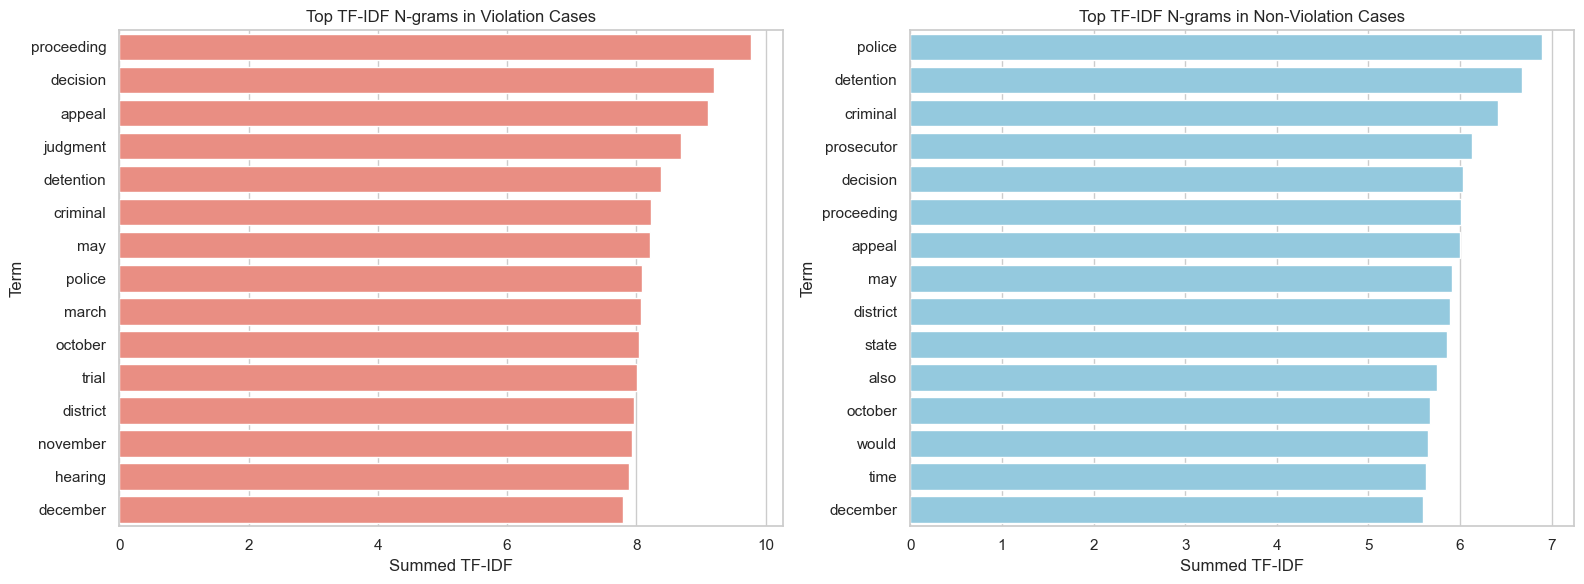

In [21]:
# Extract top words using TF-IDF for each class
violation_texts = df[df['label'] == 1]['text'].dropna()
non_violation_texts = df[df['label'] == 0]['text'].dropna()

top_v = get_top_n_tfidf(violation_texts, n=15, ngram_range=(1, 2), min_df=2)
top_nv = get_top_n_tfidf(non_violation_texts, n=15, ngram_range=(1, 2), min_df=2)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(data=top_v, x='score', y='term', ax=axes[0], color='salmon')
axes[0].set_title('Top TF-IDF N-grams in Violation Cases')
axes[0].set_xlabel('Summed TF-IDF')
axes[0].set_ylabel('Term')

sns.barplot(data=top_nv, x='score', y='term', ax=axes[1], color='skyblue')
axes[1].set_title('Top TF-IDF N-grams in Non-Violation Cases')
axes[1].set_xlabel('Summed TF-IDF')
axes[1].set_ylabel('Term')

plt.tight_layout()
plt.show()

High number of shared top terms no matter the data split. This suggests a ‘flattening’ of legal language where the Court applies a universal "schema of intelligibility" to translate localized factual realities into standardized procedural rationality. This also lends weight to a limitation outlined by Blei et al (2003): “the approach (TF-IDF) provides a relatively small amount of reduction in description length and reveals little in the way of inter- or intradocument statistical structure.”

For future analysis, we could do these approaches: (i) Pruning by implementing a ECHR-specific stopword list and tune max_df thresholds to penalize omnipresent legal boilerplate, (ii) avoid isolated word counts and use semantic embeddings (e.g. Word2Vec or Legal-BERT) to capture how these identical words may be framed differently across jurisdictions.

#### Per-Country TF-IDF Breakdown
To check whether the same keywords dominate across all three countries, we repeat the TF-IDF analysis **per country**.

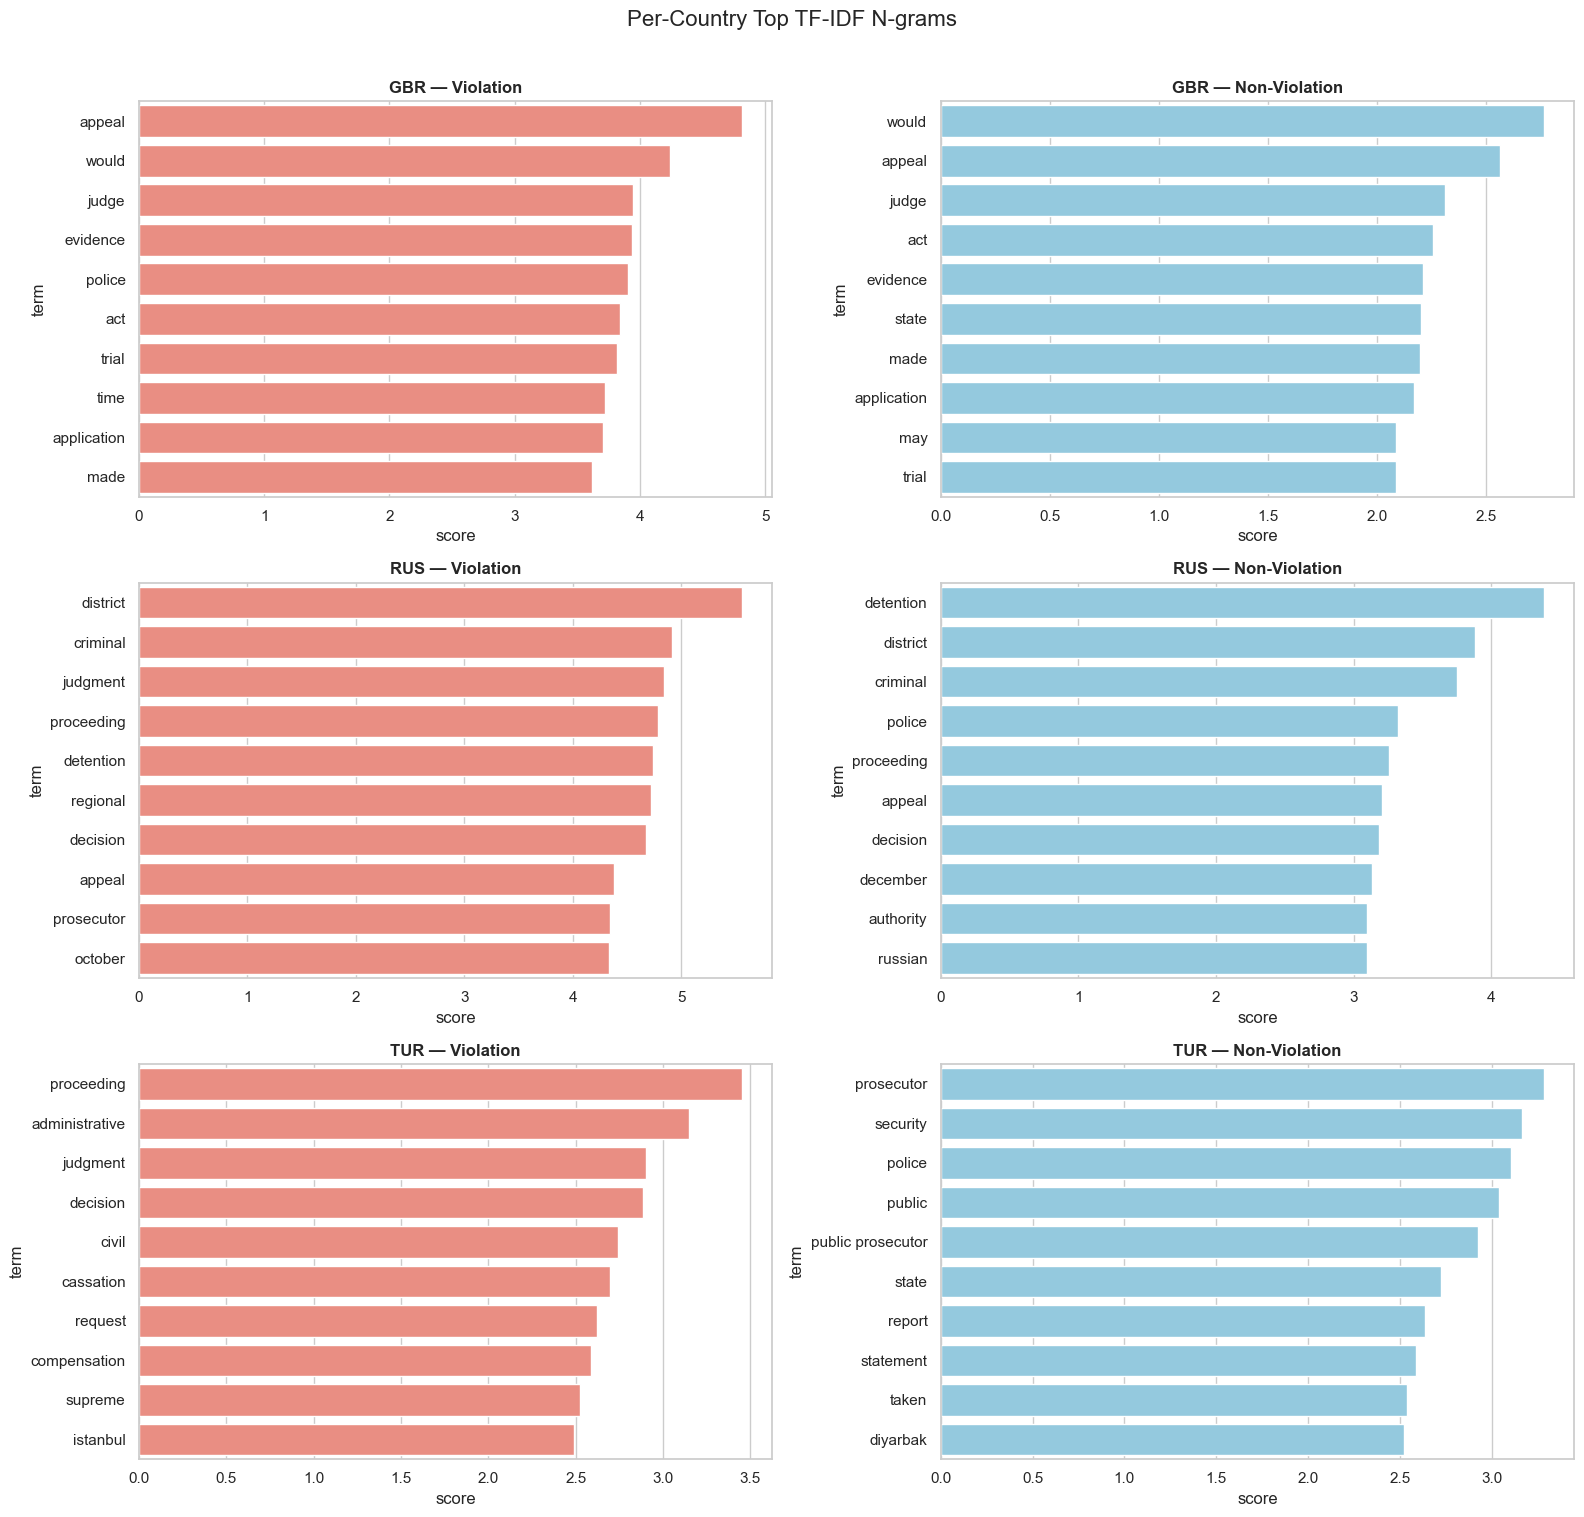

In [22]:
countries = sorted(df['respondent'].dropna().unique())
fig, axes = plt.subplots(len(countries), 2, figsize=(16, 5 * len(countries)))
axes = np.atleast_2d(axes)

for i, country in enumerate(countries):
    c_df = df[df['respondent'] == country]
    c_viol = c_df[c_df['label'] == 1]['text'].dropna()
    c_nviol = c_df[c_df['label'] == 0]['text'].dropna()

    if len(c_viol) >= 5:
        top_v = get_top_n_tfidf(c_viol, n=10, ngram_range=(1, 2), min_df=2)
        sns.barplot(data=top_v, x='score', y='term', ax=axes[i, 0], color='salmon')
    else:
        axes[i, 0].text(0.5, 0.5, f'Insufficient data (n={len(c_viol)})',
                        ha='center', va='center', transform=axes[i, 0].transAxes)
    axes[i, 0].set_title(f'{country} — Violation', fontsize=12, fontweight='bold')

    if len(c_nviol) >= 5:
        top_nv = get_top_n_tfidf(c_nviol, n=10, ngram_range=(1, 2), min_df=2)
        sns.barplot(data=top_nv, x='score', y='term', ax=axes[i, 1], color='skyblue')
    else:
        axes[i, 1].text(0.5, 0.5, f'Insufficient data (n={len(c_nviol)})',
                        ha='center', va='center', transform=axes[i, 1].transAxes)
    axes[i, 1].set_title(f'{country} — Non-Violation', fontsize=12, fontweight='bold')

plt.suptitle('Per-Country Top TF-IDF N-grams', fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

In [23]:
# Quantify overlap in top TF-IDF terms across countries
from collections import Counter
from itertools import combinations
import math

print("=" * 60)
print("TF-IDF CROSS-COUNTRY ANALYSIS")
print("=" * 60)

TOP_K = 15
MIN_CASES = 5
USE_NGRAM_RANGE = (1, 1)   # Start with unigrams for more stable interpretation

country_top_terms = {}

for country in sorted(df['respondent'].dropna().unique()):
    c_df = df[df['respondent'] == country]

    c_viol = c_df[c_df['label'] == 1]['text'].dropna()
    c_nviol = c_df[c_df['label'] == 0]['text'].dropna()

    v_terms = set()
    nv_terms = set()

    if len(c_viol) >= MIN_CASES:
        v_terms = set(
            get_top_n_tfidf(
                c_viol,
                n=TOP_K,
                ngram_range=USE_NGRAM_RANGE,
                min_df=2
            )["term"].tolist()
        )

    if len(c_nviol) >= MIN_CASES:
        nv_terms = set(
            get_top_n_tfidf(
                c_nviol,
                n=TOP_K,
                ngram_range=USE_NGRAM_RANGE,
                min_df=2
            )["term"].tolist()
        )

    country_top_terms[country] = {
        "violation": v_terms,
        "non_violation": nv_terms
    }

# Keep only countries with non-empty term sets
eligible_v = {c: d["violation"] for c, d in country_top_terms.items() if len(d["violation"]) > 0}
eligible_nv = {c: d["non_violation"] for c, d in country_top_terms.items() if len(d["non_violation"]) > 0}

print("\nEligible countries (Violation):", list(eligible_v.keys()))
print("Eligible countries (Non-Violation):", list(eligible_nv.keys()))

# ---------- Strict intersection: all countries ----------
shared_v_all = set.intersection(*eligible_v.values()) if eligible_v else set()
shared_nv_all = set.intersection(*eligible_nv.values()) if eligible_nv else set()

print(f"\nViolation — terms shared by ALL eligible countries (top {TOP_K} each): {sorted(shared_v_all) if shared_v_all else '{none}'}")
print(f"Non-Violation — terms shared by ALL eligible countries (top {TOP_K} each): {sorted(shared_nv_all) if shared_nv_all else '{none}'}")

# ---------- More useful: appears in at least 2 countries / at least half of countries ----------
def summarize_country_support(term_sets_dict, label_name):
    if not term_sets_dict:
        print(f"\n{label_name}: no eligible countries.")
        return

    counter = Counter()
    for country, terms in term_sets_dict.items():
        counter.update(terms)

    n_countries = len(term_sets_dict)
    half_threshold = max(2, math.ceil(n_countries / 2))

    top_shared_2 = sorted(
        [(t, c) for t, c in counter.items() if c >= 2],
        key=lambda x: (-x[1], x[0])
    )[:20]

    top_shared_half = sorted(
        [(t, c) for t, c in counter.items() if c >= half_threshold],
        key=lambda x: (-x[1], x[0])
    )[:20]

    print(f"\n{label_name} — terms appearing in at least 2 countries:")
    print(top_shared_2 if top_shared_2 else "{none}")

    print(f"\n{label_name} — terms appearing in at least half of countries (threshold={half_threshold}/{n_countries}):")
    print(top_shared_half if top_shared_half else "{none}")

summarize_country_support(eligible_v, "Violation")
summarize_country_support(eligible_nv, "Non-Violation")

# ---------- Pairwise overlap ----------
print("\nPairwise overlap:")
for a, b in combinations(sorted(country_top_terms.keys()), 2):
    ov = len(country_top_terms[a]['violation'] & country_top_terms[b]['violation'])
    onv = len(country_top_terms[a]['non_violation'] & country_top_terms[b]['non_violation'])
    print(f"  {a} ∩ {b}: {ov}/{TOP_K} Violation shared, {onv}/{TOP_K} Non-Violation shared")

TF-IDF CROSS-COUNTRY ANALYSIS

Eligible countries (Violation): ['GBR', 'RUS', 'TUR']
Eligible countries (Non-Violation): ['GBR', 'RUS', 'TUR']

Violation — terms shared by ALL eligible countries (top 15 each): ['decision']
Non-Violation — terms shared by ALL eligible countries (top 15 each): {none}

Violation — terms appearing in at least 2 countries:
[('decision', 3), ('appeal', 2), ('detention', 2), ('judgment', 2), ('march', 2), ('may', 2), ('october', 2), ('proceeding', 2), ('trial', 2)]

Violation — terms appearing in at least half of countries (threshold=2/3):
[('decision', 3), ('appeal', 2), ('detention', 2), ('judgment', 2), ('march', 2), ('may', 2), ('october', 2), ('proceeding', 2), ('trial', 2)]

Non-Violation — terms appearing in at least 2 countries:
[('appeal', 2), ('criminal', 2), ('decision', 2), ('may', 2), ('police', 2), ('state', 2), ('trial', 2)]

Non-Violation — terms appearing in at least half of countries (threshold=2/3):
[('appeal', 2), ('criminal', 2), ('decisi

#### Per-Article TF-IDF Breakdown
Do different ECHR articles produce different top TF-IDF terms? We repeat the analysis **per article type** (Art 3/5/6/8).

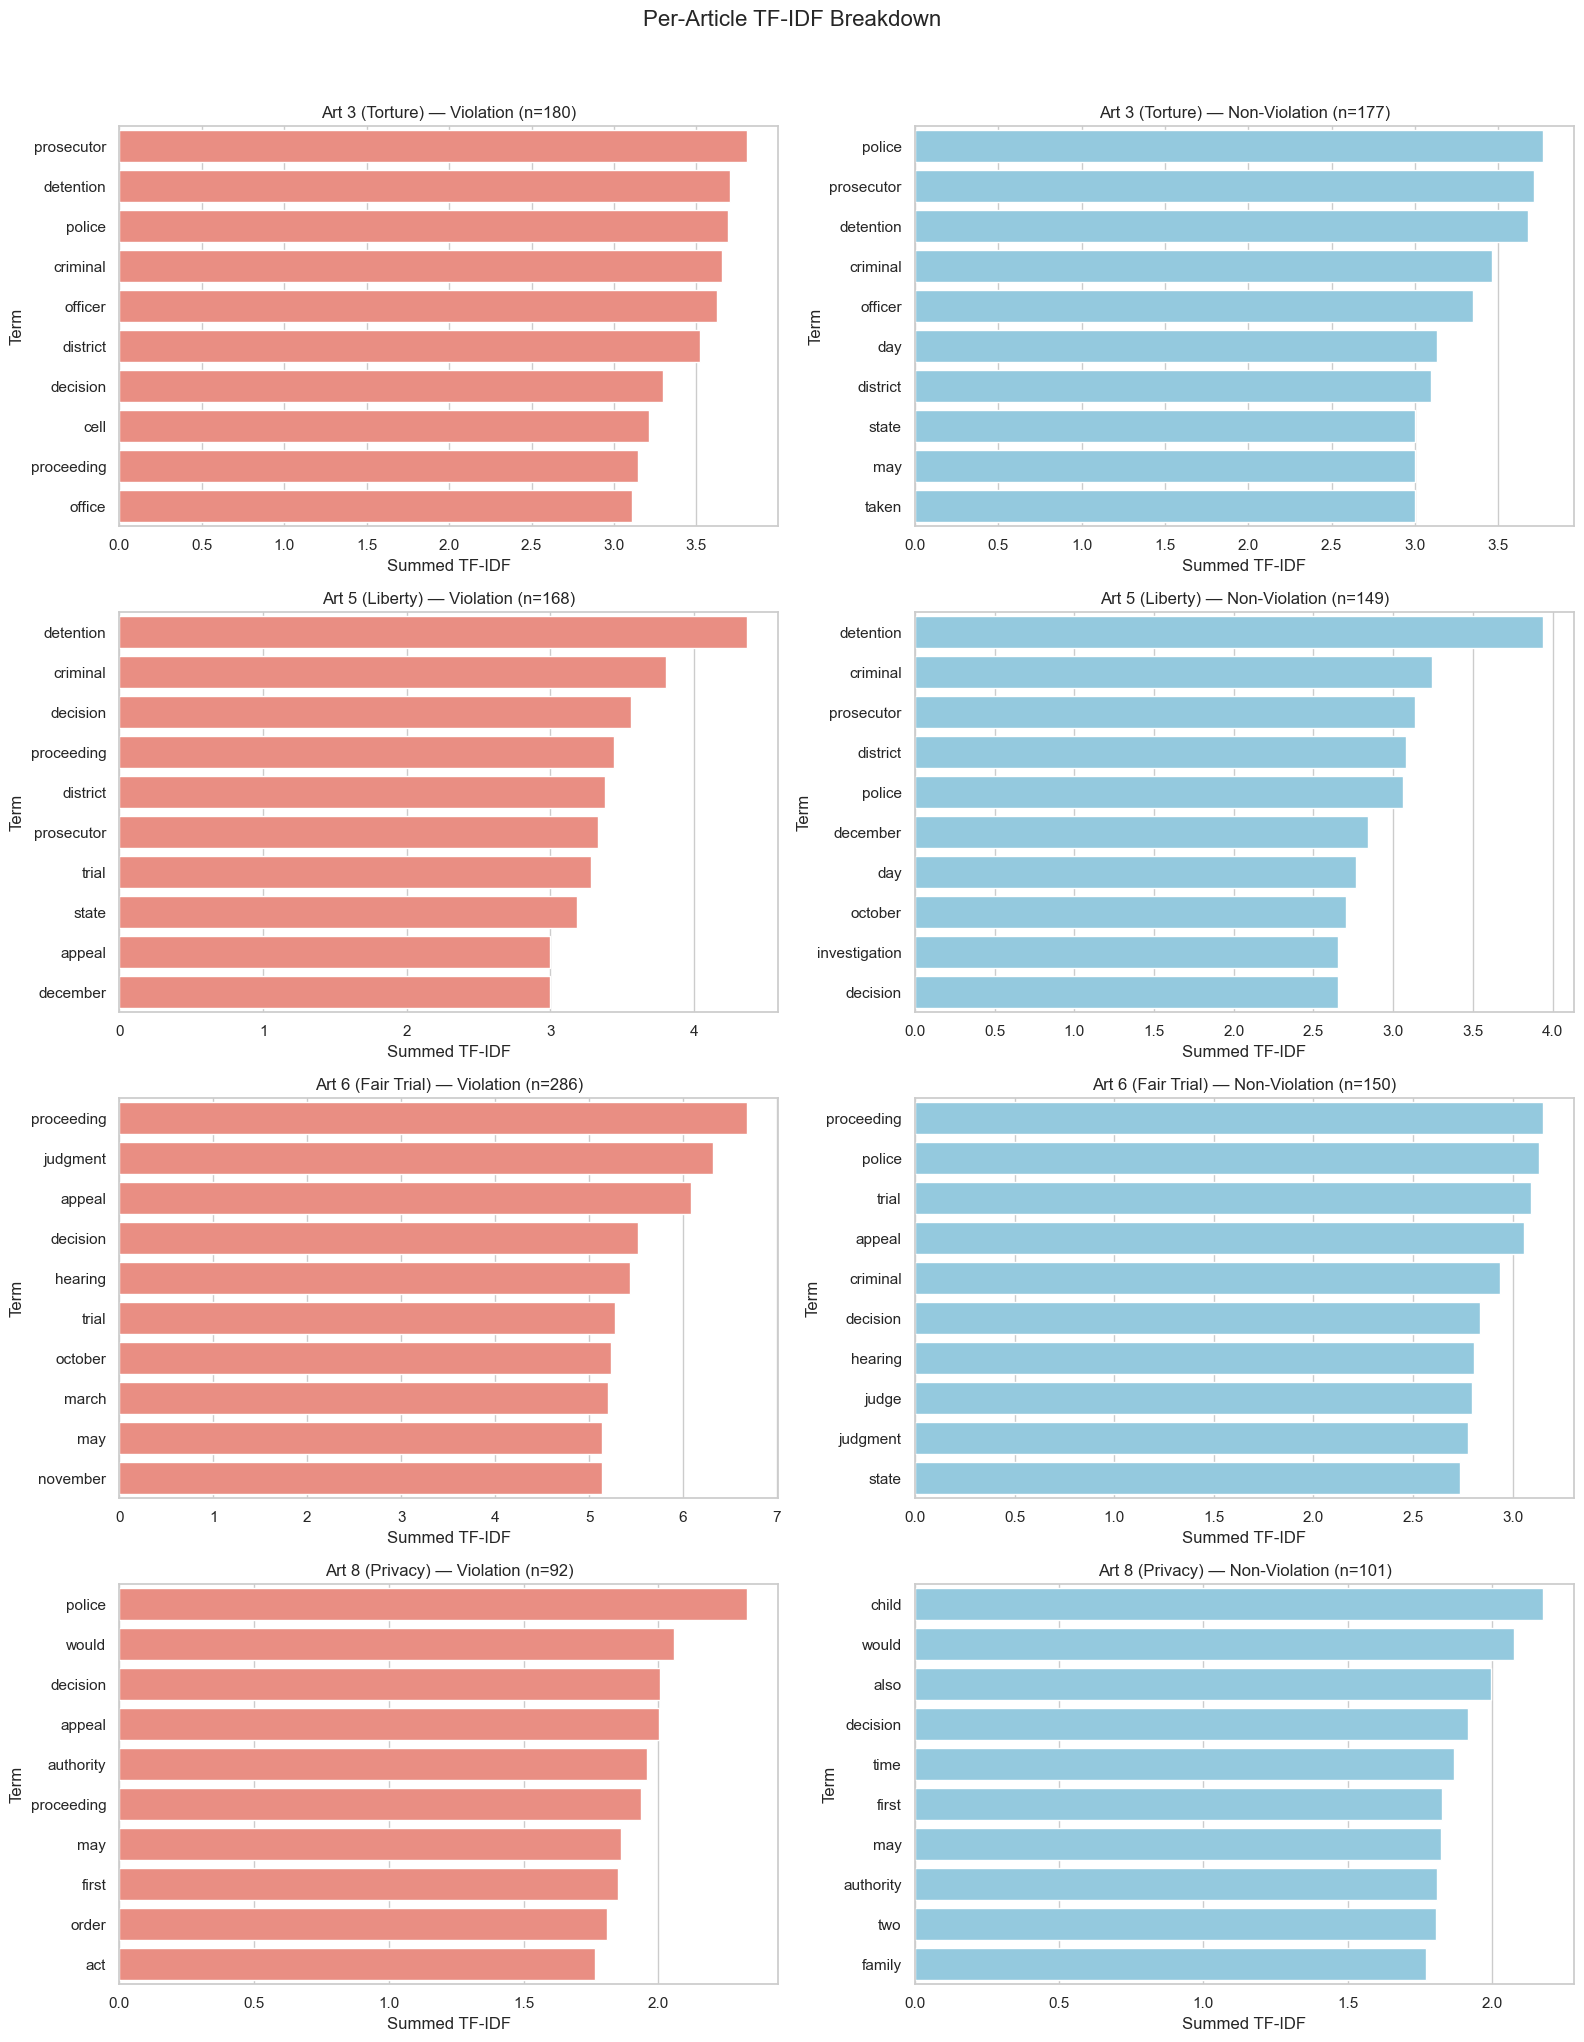

Art 3 (Torture)
Total cases: 357
Violation cases: 180
Non-Violation cases: 177
Top Violation terms: ['prosecutor', 'detention', 'police', 'criminal', 'officer', 'district', 'decision', 'cell', 'proceeding', 'office']
Top Non-Violation terms: ['police', 'prosecutor', 'detention', 'criminal', 'officer', 'day', 'district', 'state', 'may', 'taken']
Art 5 (Liberty)
Total cases: 317
Violation cases: 168
Non-Violation cases: 149
Top Violation terms: ['detention', 'criminal', 'decision', 'proceeding', 'district', 'prosecutor', 'trial', 'state', 'appeal', 'december']
Top Non-Violation terms: ['detention', 'criminal', 'prosecutor', 'district', 'police', 'december', 'day', 'october', 'investigation', 'decision']
Art 6 (Fair Trial)
Total cases: 436
Violation cases: 286
Non-Violation cases: 150
Top Violation terms: ['proceeding', 'judgment', 'appeal', 'decision', 'hearing', 'trial', 'october', 'march', 'may', 'november']
Top Non-Violation terms: ['proceeding', 'police', 'trial', 'appeal', 'criminal

In [24]:
# Per-Article TF-IDF Breakdown
n_articles = len(article_map)
fig, axes = plt.subplots(n_articles, 2, figsize=(16, 5 * n_articles))
axes = np.atleast_2d(axes)

summary_tables = {}

for i, (art_num, art_name) in enumerate(article_map.items()):
    mask = (
        article_mask(df['violation_articles'], art_num) |
        article_mask(df['nonviolation_articles'], art_num)
    )
    a_df = df.loc[mask].copy()

    a_viol = a_df.loc[a_df['label'] == 1, 'text'].dropna()
    a_nviol = a_df.loc[a_df['label'] == 0, 'text'].dropna()

    if len(a_viol) >= 5:
        top_v = get_top_n_tfidf(a_viol, n=10, ngram_range=(1, 2), min_df=2)
        sns.barplot(data=top_v, x="score", y="term", ax=axes[i, 0], color="salmon")
        top_v_terms = top_v["term"].tolist()
    else:
        axes[i, 0].text(0.5, 0.5, f"Insufficient data (n={len(a_viol)})",
                        ha="center", va="center", transform=axes[i, 0].transAxes)
        top_v_terms = []
    axes[i, 0].set_title(f"{art_name} — Violation (n={len(a_viol)})")
    axes[i, 0].set_xlabel("Summed TF-IDF")
    axes[i, 0].set_ylabel("Term")

    if len(a_nviol) >= 5:
        top_nv = get_top_n_tfidf(a_nviol, n=10, ngram_range=(1, 2), min_df=2)
        sns.barplot(data=top_nv, x="score", y="term", ax=axes[i, 1], color="skyblue")
        top_nv_terms = top_nv["term"].tolist()
    else:
        axes[i, 1].text(0.5, 0.5, f"Insufficient data (n={len(a_nviol)})",
                        ha="center", va="center", transform=axes[i, 1].transAxes)
        top_nv_terms = []
    axes[i, 1].set_title(f"{art_name} — Non-Violation (n={len(a_nviol)})")
    axes[i, 1].set_xlabel("Summed TF-IDF")
    axes[i, 1].set_ylabel("Term")

    summary_tables[art_name] = {
        "total_cases": len(a_df),
        "violation_cases": len(a_viol),
        "nonviolation_cases": len(a_nviol),
        "top_violation_terms": top_v_terms,
        "top_nonviolation_terms": top_nv_terms,
    }

plt.suptitle("Per-Article TF-IDF Breakdown", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

for art_name, info in summary_tables.items():
    print("=" * 80)
    print(art_name)
    print(f"Total cases: {info['total_cases']}")
    print(f"Violation cases: {info['violation_cases']}")
    print(f"Non-Violation cases: {info['nonviolation_cases']}")
    print(f"Top Violation terms: {info['top_violation_terms']}")
    print(f"Top Non-Violation terms: {info['top_nonviolation_terms']}")

## 6.3 Fighting Words and Shifterator
To visualize words that most distinguish the two classes, we use the `shifterator` library to plot **Jensen-Shannon Divergence (JSD) Shifts**. 

**How to read the chart:**
- Words pointing **right** (positive) are more characteristic of **Violation** cases
- Words pointing **left** (negative) are more characteristic of **Non-Violation** cases
- The **length** of each bar indicates how much that word contributes to the overall divergence between the two classes
- Words near the top contribute the most to distinguishing the two categories

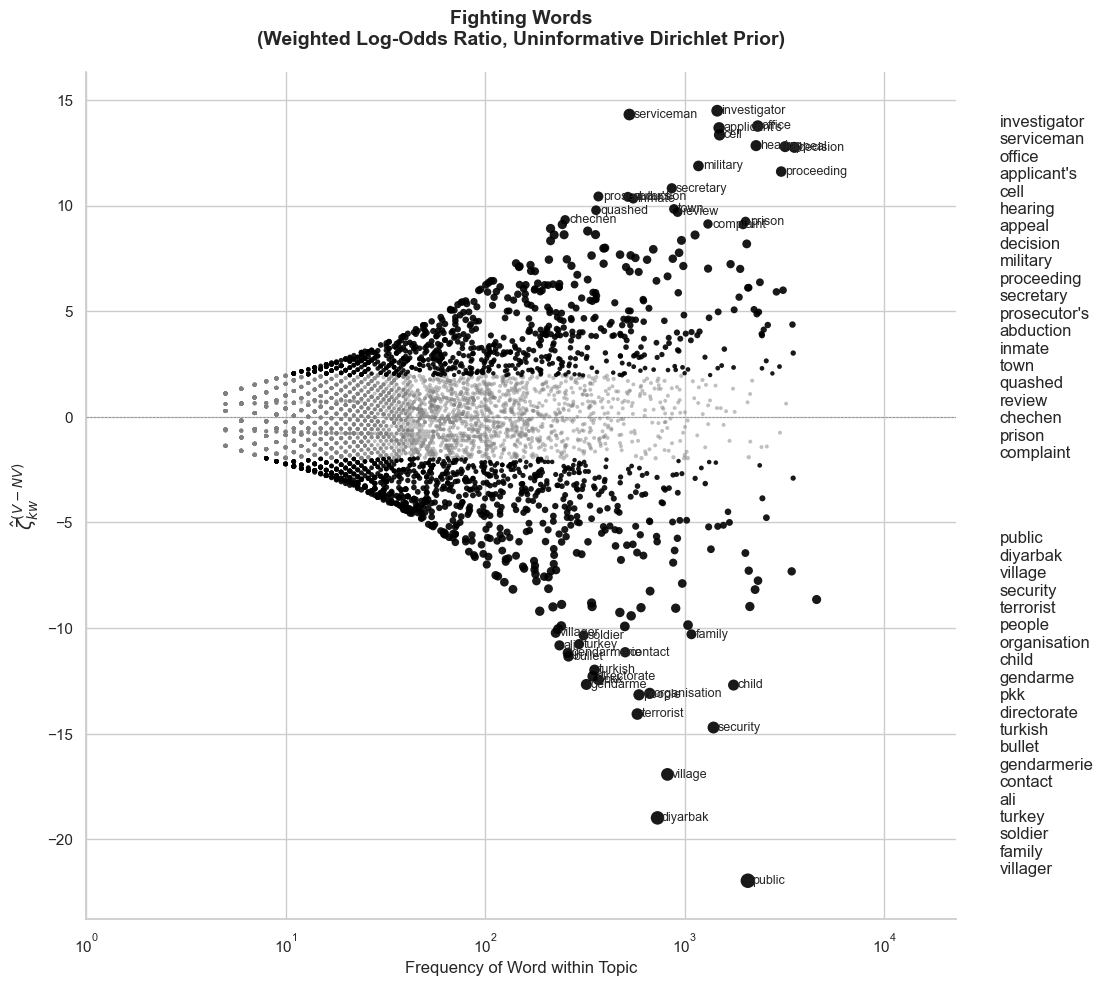

Top Violation fighting words


,term,z_score,total_freq,v_count,nv_count
0,investigator,14.487032,1458.0,1068.0,390.0
1,serviceman,14.306790,529.0,489.0,40.0
2,office,13.761885,2329.0,1588.0,741.0
3,applicant's,13.677282,1490.0,1071.0,419.0
4,cell,13.343625,1498.0,1069.0,429.0
5,hearing,12.835266,2283.0,1537.0,746.0
6,appeal,12.789108,3192.0,2079.0,1113.0
7,decision,12.752454,3554.0,2292.0,1262.0
8,military,11.873316,1174.0,839.0,335.0
9,proceeding,11.607960,3051.0,1962.0,1089.0


Top Non-Violation fighting words


,term,z_score,total_freq,v_count,nv_count
0,public,-21.956543,2077.0,596.0,1481.0
1,diyarbak,-18.982121,732.0,54.0,678.0
2,village,-16.925125,821.0,179.0,642.0
3,security,-14.705499,1397.0,470.0,927.0
4,terrorist,-14.067338,580.0,129.0,451.0
5,people,-13.157385,591.0,148.0,443.0
6,organisation,-13.088867,669.0,182.0,487.0
7,child,-12.696076,1761.0,678.0,1083.0
8,gendarme,-12.665953,322.0,29.0,293.0
9,pkk,-12.450287,371.0,14.0,357.0


In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer

def fighting_words_plot_uninformative(texts_v, texts_nv, top_n=20, prior_alpha=0.01, min_df=5, max_df=0.9):
    """
    Monroe et al. (2008) fighting words with an uninformative Dirichlet prior.
    Reuses the notebook's shared lexical pipeline via build_vectorizer().
    """

    # -----------------------------------------------------
    # 1. Normalize input type
    # -----------------------------------------------------
    texts_v = pd.Series(texts_v).dropna().astype(str)
    texts_nv = pd.Series(texts_nv).dropna().astype(str)

    if len(texts_v) == 0 or len(texts_nv) == 0:
        raise ValueError("Both texts_v and texts_nv must contain at least one non-empty document.")

    all_texts = pd.concat([texts_v, texts_nv], ignore_index=True)

    # -----------------------------------------------------
    # 2. Build shared vocabulary using the notebook helper
    #    This ensures consistency with legal_tokenizer / lemmatization / stopwords
    # -----------------------------------------------------
    vec = build_vectorizer(
        CountVectorizer,
        ngram_range=(1, 1),   # fighting words here should stay unigram unless you explicitly want bigrams
        min_df=min_df,
        max_df=max_df
    )
    vec.fit(all_texts)

    vocab = np.array(vec.get_feature_names_out())

    X_v = vec.transform(texts_v)
    X_nv = vec.transform(texts_nv)

    # -----------------------------------------------------
    # 3. Aggregate counts per class
    # -----------------------------------------------------
    y_v = np.asarray(X_v.sum(axis=0)).ravel().astype(float)
    y_nv = np.asarray(X_nv.sum(axis=0)).ravel().astype(float)

    n_v = y_v.sum()
    n_nv = y_nv.sum()

    if n_v == 0 or n_nv == 0:
        raise ValueError("One class has zero total token count after preprocessing.")

    y_total = y_v + y_nv
    V = len(vocab)

    # -----------------------------------------------------
    # 4. Monroe-style weighted log-odds with uninformative prior
    #    alpha is applied uniformly to every term
    # -----------------------------------------------------
    alpha = float(prior_alpha)

    delta = (
        np.log((y_v + alpha) / (n_v + alpha * V - y_v - alpha))
        - np.log((y_nv + alpha) / (n_nv + alpha * V - y_nv - alpha))
    )

    variance = 1.0 / (y_v + alpha) + 1.0 / (y_nv + alpha)
    z_scores = delta / np.sqrt(variance)

    # -----------------------------------------------------
    # 5. Prepare top words
    # -----------------------------------------------------
    sorted_idx = np.argsort(z_scores)

    top_nv_idx = sorted_idx[:top_n]               # most negative => Non-Violation
    top_v_idx = sorted_idx[-top_n:][::-1]         # most positive => Violation

    top_v_df = pd.DataFrame({
        "term": vocab[top_v_idx],
        "z_score": z_scores[top_v_idx],
        "total_freq": y_total[top_v_idx],
        "v_count": y_v[top_v_idx],
        "nv_count": y_nv[top_v_idx],
    })

    top_nv_df = pd.DataFrame({
        "term": vocab[top_nv_idx],
        "z_score": z_scores[top_nv_idx],
        "total_freq": y_total[top_nv_idx],
        "v_count": y_v[top_nv_idx],
        "nv_count": y_nv[top_nv_idx],
    }).sort_values("z_score")

    # -----------------------------------------------------
    # 6. Plot
    # -----------------------------------------------------
    fig, ax = plt.subplots(figsize=(12, 11))

    sig_mask = np.abs(z_scores) >= 1.96
    insig_mask = ~sig_mask

    sizes = np.clip(np.abs(z_scores) * 5, 8, None)

    ax.scatter(
        y_total[insig_mask], z_scores[insig_mask],
        c="gray", s=sizes[insig_mask], alpha=0.5, edgecolors="none"
    )
    ax.scatter(
        y_total[sig_mask], z_scores[sig_mask],
        c="black", s=sizes[sig_mask], alpha=0.9, edgecolors="none"
    )

    for idx in top_v_idx:
        ax.text(y_total[idx] * 1.05, z_scores[idx], vocab[idx], fontsize=9, va="center")

    for idx in top_nv_idx:
        ax.text(y_total[idx] * 1.05, z_scores[idx], vocab[idx], fontsize=9, va="center")

    ax.set_xscale("log")
    ax.axhline(0, color="gray", linestyle="--", linewidth=0.5)
    ax.set_xlim(left=1, right=max(np.max(y_total) * 5, 10))

    ax.set_title(
        "Fighting Words\n(Weighted Log-Odds Ratio, Uninformative Dirichlet Prior)",
        fontsize=14, pad=20, fontweight="bold"
    )
    ax.set_ylabel(r'$\hat{\zeta}^{(V - NV)}_{kw}$', fontsize=14)
    ax.set_xlabel("Frequency of Word within Topic", fontsize=12)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    # right-side word list
    list_x = 1.05
    v_words_str = "\n".join(top_v_df["term"].tolist())
    nv_words_str = "\n".join(top_nv_df["term"].tolist())

    ax.text(
        list_x, 0.95, v_words_str,
        transform=ax.transAxes, fontsize=12, va="top", ha="left", family="sans-serif"
    )
    ax.text(
        list_x, 0.05, nv_words_str,
        transform=ax.transAxes, fontsize=12, va="bottom", ha="left", family="sans-serif"
    )

    plt.subplots_adjust(right=0.85)
    plt.show()

    return top_v_df, top_nv_df

# ---------------------------------------------------------
# Run
# ---------------------------------------------------------
violation_texts = df.loc[df["label"] == 1, "text"].dropna()
non_violation_texts = df.loc[df["label"] == 0, "text"].dropna()

top_v, top_nv = fighting_words_plot_uninformative(
    violation_texts,
    non_violation_texts,
    top_n=20,
    prior_alpha=0.01,
    min_df=5,
    max_df=0.9
)

print("=" * 80)
print("Top Violation fighting words")
print("=" * 80)
display(top_v)

print("=" * 80)
print("Top Non-Violation fighting words")
print("=" * 80)
display(top_nv)

These visualisations challenge legal texts as being an objective, universal legal reality:


Violation Predictors: Militarized and severe procedural actions (e.g., "serviceman", "investigator", "military", "abduction", "cell", "chechen").
Non-Violation Predictors: Hyper-localized and geographical conflict terminology (e.g., "diyarbakir", "pkk", "gendarmerie", "terrorist", "village") and a notable conditional verb ("would").

These showcase geopolitical spuriousness and a model may merely map historical clusters (e.g., the Kurdish conflict, the Cyprus dispute) over true legal reasoning. Further, the use of “would” in non-violation cases also lends weight to post-factual narratives, and also suggests judges will tend to use conditional, counterfactual logic (e.g. "The applicant would have had to...") to justify why a complaint fails.


/opt/anaconda3/envs/LLX39/lib/python3.9/site-packages/shifterator/plotting.py:604: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(x_ticks, fontsize=plot_params["xtick_fontsize"])


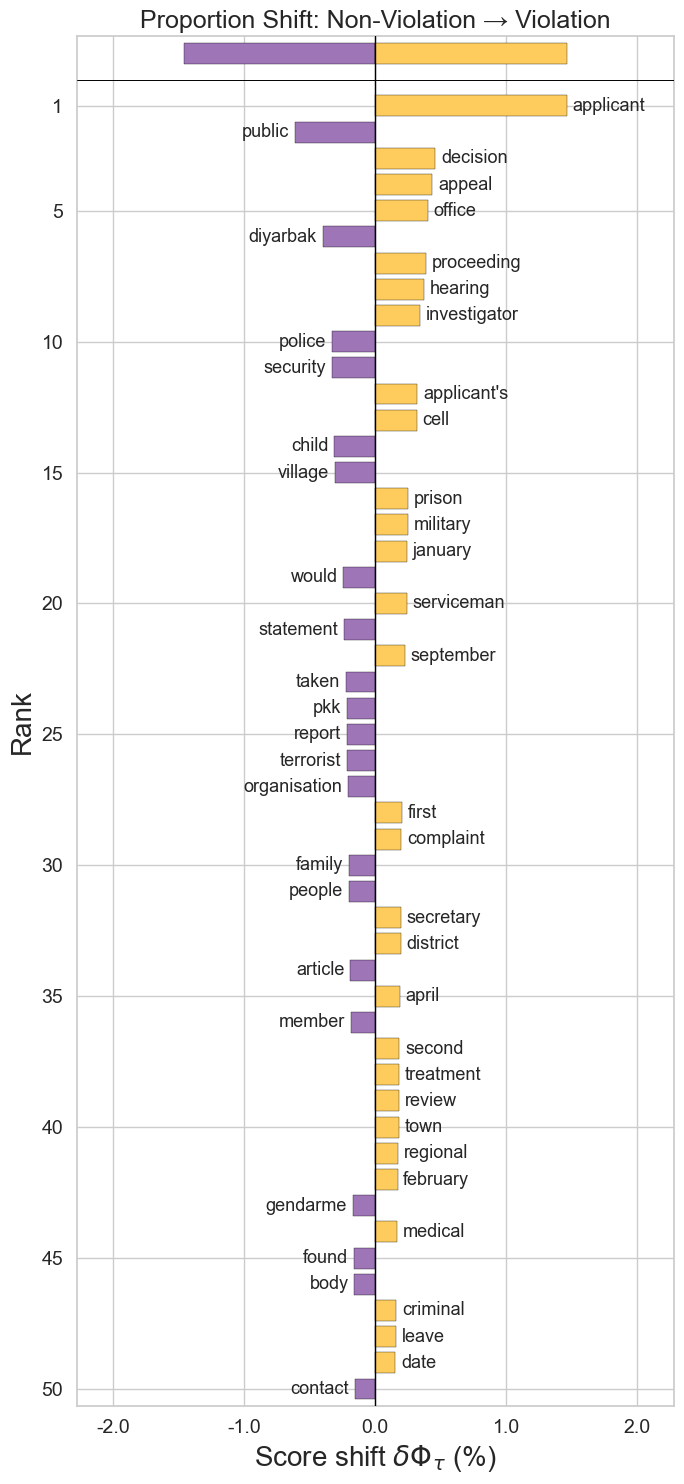

In [27]:
# Clean and count for Shifterator using the SAME tokenizer / lemmatizer pipeline
count_v = get_counts(violation_texts)
count_nv = get_counts(non_violation_texts)

prop_shift = sh.ProportionShift(type2freq_1=count_nv, type2freq_2=count_v)
prop_shift.get_shift_graph(
    system_names=['Non-Violation', 'Violation'],
    title='Proportion Shift: Non-Violation → Violation',
    cumulative_inset=False,
    text_size_inset=False
)
plt.show()

#### Per-Country Shifterator
To verify whether the same words distinguish Violation from Non-Violation across all three countries, we produce a **Proportion Shift** chart for each country separately.

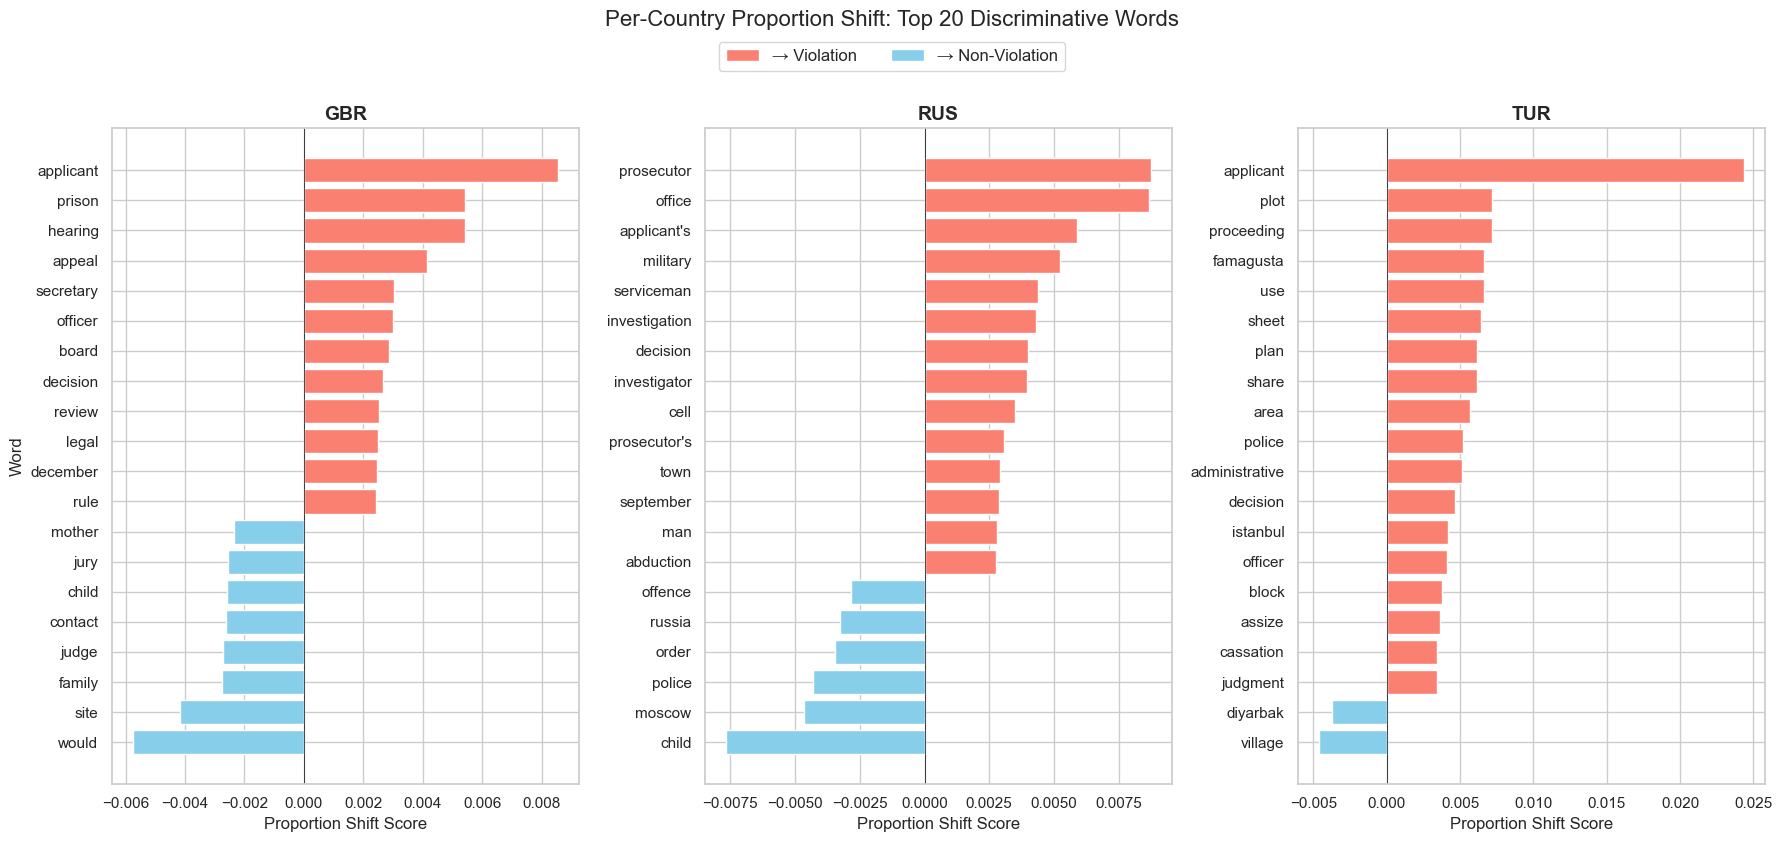

In [28]:
countries = sorted(df['respondent'].dropna().unique())
fig, axes = plt.subplots(1, len(countries), figsize=(6 * len(countries), 8))
axes = np.atleast_1d(axes)

for idx, country in enumerate(countries):
    c_df = df[df['respondent'] == country]
    c_viol = c_df[c_df['label'] == 1]['text'].dropna()
    c_nviol = c_df[c_df['label'] == 0]['text'].dropna()

    c_count_v = get_counts(c_viol)
    c_count_nv = get_counts(c_nviol)

    try:
        ps = sh.ProportionShift(type2freq_1=c_count_nv, type2freq_2=c_count_v)
        scores = ps.type2shift_score
        sorted_scores = sorted(scores.items(), key=lambda x: abs(x[1]), reverse=True)[:20]
        sorted_scores = sorted(sorted_scores, key=lambda x: x[1])
        words = [w for w, s in sorted_scores]
        vals = [s for w, s in sorted_scores]
        colors = ['salmon' if v > 0 else 'skyblue' for v in vals]

        axes[idx].barh(words, vals, color=colors)
        axes[idx].axvline(x=0, color='black', linewidth=0.5)
        axes[idx].set_title(f'{country}', fontsize=14, fontweight='bold')
        axes[idx].set_xlabel('Proportion Shift Score')
        if idx == 0:
            axes[idx].set_ylabel('Word')
    except Exception as e:
        axes[idx].text(0.5, 0.5, f'{country}: {e}', ha='center', va='center', transform=axes[idx].transAxes)
        axes[idx].set_title(f'{country}', fontsize=14, fontweight='bold')

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='salmon', label='→ Violation'),
    Patch(facecolor='skyblue', label='→ Non-Violation')
]
fig.legend(handles=legend_elements, loc='upper center', ncol=2, fontsize=12, bbox_to_anchor=(0.5, 1.02))
plt.suptitle('Per-Country Proportion Shift: Top 20 Discriminative Words', fontsize=16, y=1.05)
plt.tight_layout()
plt.show()

In [29]:
# Quantify top discriminative words across countries
print("=" * 60)
print("SHIFTERATOR WORDS CROSS-COUNTRY ANALYSIS")
print("=" * 60)

country_shift_words = {}
for country in sorted(df['respondent'].dropna().unique()):
    c_df = df[df['respondent'] == country]
    c_viol = c_df[c_df['label'] == 1]['text'].dropna()
    c_nviol = c_df[c_df['label'] == 0]['text'].dropna()
    c_count_v = get_counts(c_viol)
    c_count_nv = get_counts(c_nviol)
    try:
        ps = sh.ProportionShift(type2freq_1=c_count_nv, type2freq_2=c_count_v)
        scores = ps.type2shift_score
        sorted_scores = sorted(scores.items(), key=lambda x: abs(x[1]), reverse=True)
        top20 = sorted_scores[:20]
        country_shift_words[country] = set(w for w, _ in top20)

        pos_words = [w for w, s in sorted_scores if s > 0][:5]
        neg_words = [w for w, s in sorted_scores if s < 0][:5]
        print(f"\n{country}:")
        print(f"  Top Violation words: {', '.join(pos_words) if pos_words else '{none}'}")
        print(f"  Top Non-Violation words: {', '.join(neg_words) if neg_words else '{none}'}")
    except Exception as e:
        print(f"{country}: Analysis failed — {e}")

if len(country_shift_words) > 1:
    countries = sorted(country_shift_words.keys())
    shared = set.intersection(*country_shift_words.values())
    print(f"\nTop-20 discriminative words shared by ALL countries: {shared if shared else '{none}'}")

    from itertools import combinations
    for a, b in combinations(countries, 2):
        overlap = len(country_shift_words[a] & country_shift_words[b])
        print(f"  {a} ∩ {b}: {overlap}/20 top discriminative words shared")

    if shared:
        print("\n→ Shared discriminative words across countries are strong candidates for spurious shortcuts.")
        print("  These should be prioritized in ablation testing during modeling.")
    else:
        print("\n→ Each country has a distinct discriminative vocabulary, suggesting models may learn")
        print("  country-specific patterns rather than universal legal reasoning.")

SHIFTERATOR WORDS CROSS-COUNTRY ANALYSIS

GBR:
  Top Violation words: applicant, prison, hearing, appeal, secretary
  Top Non-Violation words: would, site, family, judge, contact

RUS:
  Top Violation words: prosecutor, office, applicant's, military, serviceman
  Top Non-Violation words: child, moscow, police, order, russia

TUR:
  Top Violation words: applicant, plot, proceeding, famagusta, use
  Top Non-Violation words: village, diyarbak, statement, witness, investigation

Top-20 discriminative words shared by ALL countries: {'decision'}
  GBR ∩ RUS: 2/20 top discriminative words shared
  GBR ∩ TUR: 3/20 top discriminative words shared
  RUS ∩ TUR: 2/20 top discriminative words shared

→ Shared discriminative words across countries are strong candidates for spurious shortcuts.
  These should be prioritized in ablation testing during modeling.


#### Per-Article Shifterator Words
Do different ECHR articles (Art 3/5/6/8) produce different discriminative vocabularies? We compute a **Proportion Shift** for each article separately, comparing Violation vs Non-Violation texts within that article category.

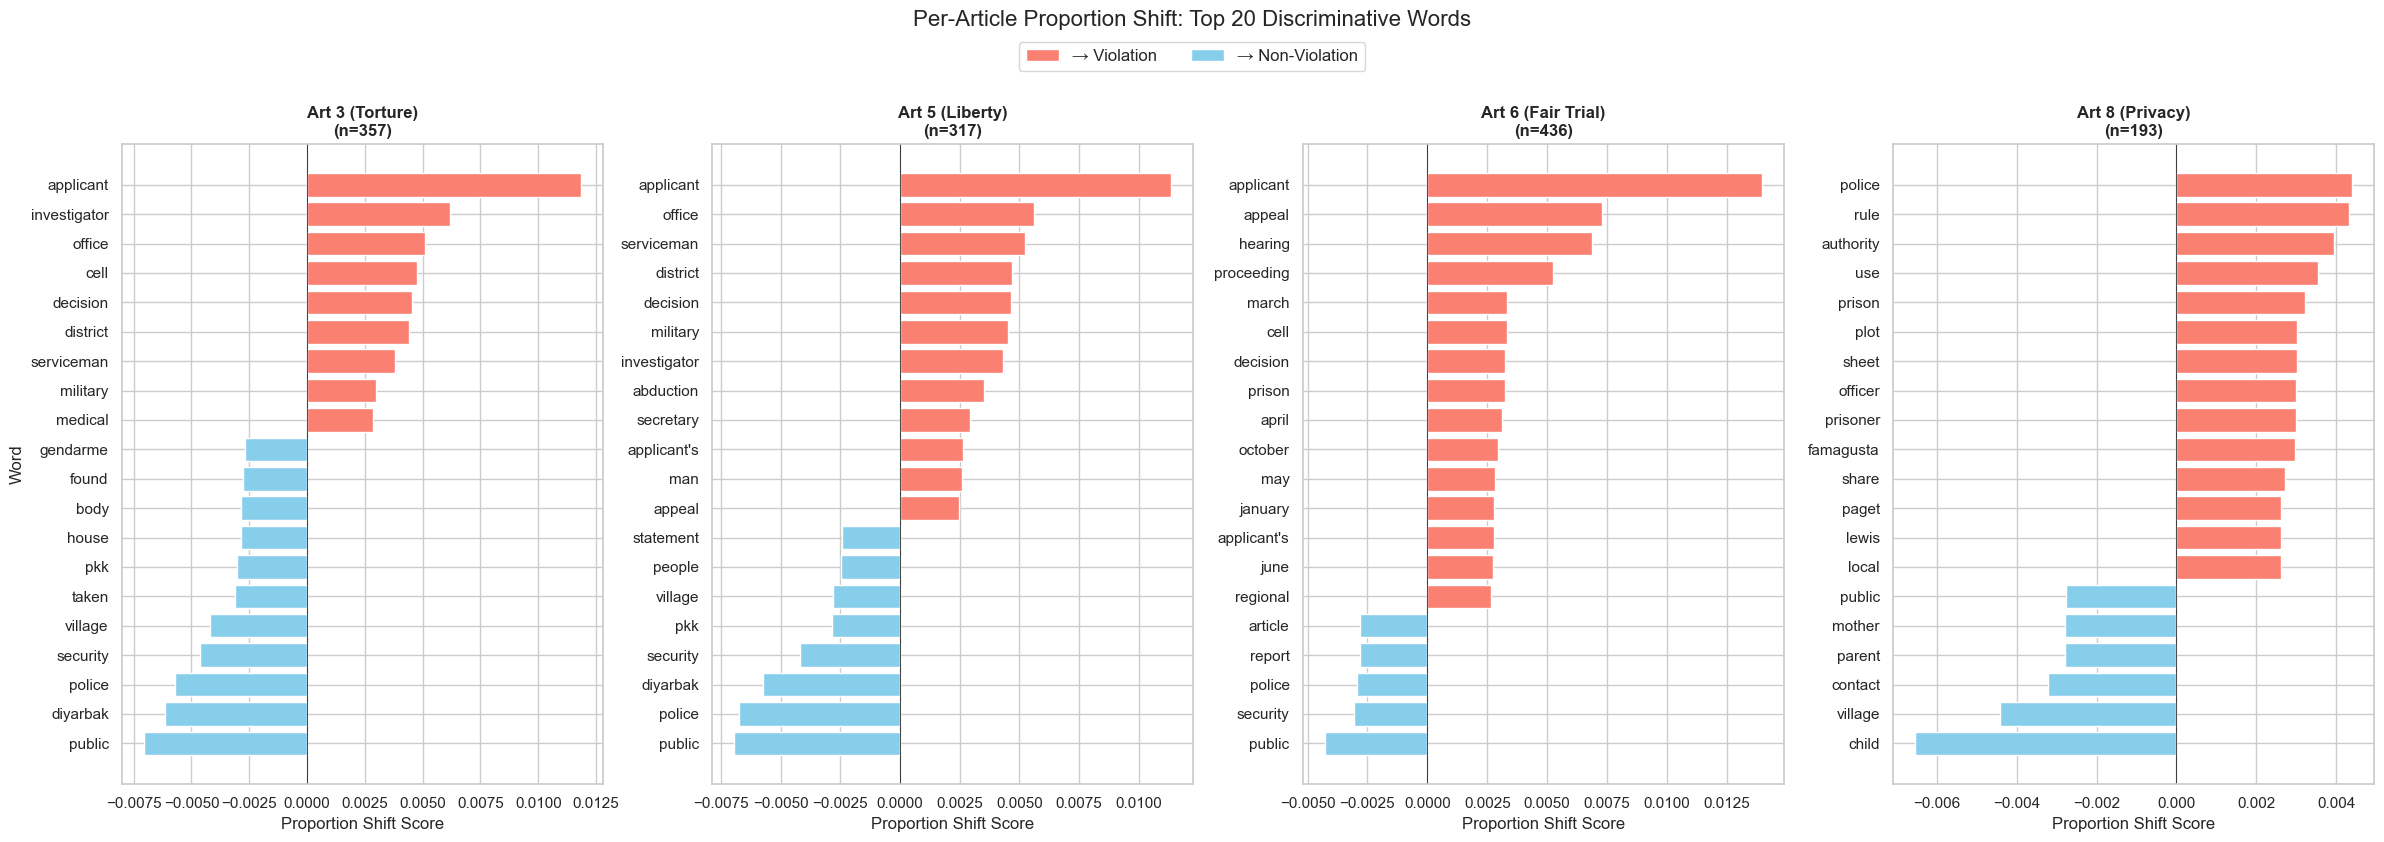

SHIFTERATOR WORDS CROSS-ARTICLE ANALYSIS

Art 3 (Torture): 20 top discriminative words

Art 5 (Liberty): 20 top discriminative words

Art 6 (Fair Trial): 20 top discriminative words

Art 8 (Privacy): 20 top discriminative words

Shared across ALL articles: {'public', 'police'}
  Art 3 (Torture) ∩ Art 5 (Liberty): 13/20 shared
  Art 3 (Torture) ∩ Art 6 (Fair Trial): 6/20 shared
  Art 3 (Torture) ∩ Art 8 (Privacy): 3/20 shared
  Art 5 (Liberty) ∩ Art 6 (Fair Trial): 7/20 shared
  Art 5 (Liberty) ∩ Art 8 (Privacy): 3/20 shared
  Art 6 (Fair Trial) ∩ Art 8 (Privacy): 3/20 shared

→ Words shared across ALL article types are likely generic legal language,
  not article-specific reasoning. Consider removing them in ablation tests.


In [30]:
# Per-Article Fighting Words
fig, axes = plt.subplots(1, len(article_map), figsize=(6 * len(article_map), 8))
axes = np.atleast_1d(axes)

article_shift_words = {}
for idx, (art_num, art_name) in enumerate(article_map.items()):
    mask = (
        article_mask(df['violation_articles'], art_num) |
        article_mask(df['nonviolation_articles'], art_num)
    )
    a_df = df[mask]
    a_viol = a_df[a_df['label'] == 1]['text'].dropna()
    a_nviol = a_df[a_df['label'] == 0]['text'].dropna()

    if len(a_viol) < 5 or len(a_nviol) < 5:
        axes[idx].text(0.5, 0.5, f'{art_name}:\nInsufficient data',
                       ha='center', va='center', transform=axes[idx].transAxes)
        axes[idx].set_title(art_name, fontsize=12, fontweight='bold')
        continue

    a_count_v = get_counts(a_viol)
    a_count_nv = get_counts(a_nviol)

    try:
        ps = sh.ProportionShift(type2freq_1=a_count_nv, type2freq_2=a_count_v)
        scores = ps.type2shift_score
        sorted_scores = sorted(scores.items(), key=lambda x: abs(x[1]), reverse=True)[:20]
        sorted_scores = sorted(sorted_scores, key=lambda x: x[1])
        words = [w for w, s in sorted_scores]
        vals = [s for w, s in sorted_scores]
        colors = ['salmon' if v > 0 else 'skyblue' for v in vals]

        axes[idx].barh(words, vals, color=colors)
        axes[idx].axvline(x=0, color='black', linewidth=0.5)
        axes[idx].set_title(f'{art_name}\n(n={len(a_df)})', fontsize=12, fontweight='bold')
        axes[idx].set_xlabel('Proportion Shift Score')
        if idx == 0:
            axes[idx].set_ylabel('Word')

        article_shift_words[art_name] = set(w for w, _ in sorted(scores.items(), key=lambda x: abs(x[1]), reverse=True)[:20])
    except Exception as e:
        axes[idx].text(0.5, 0.5, f'{art_name}: {e}', ha='center', va='center', transform=axes[idx].transAxes)
        axes[idx].set_title(art_name, fontsize=12, fontweight='bold')

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='salmon', label='→ Violation'),
    Patch(facecolor='skyblue', label='→ Non-Violation')
]
fig.legend(handles=legend_elements, loc='upper center', ncol=2, fontsize=12, bbox_to_anchor=(0.5, 1.02))
plt.suptitle('Per-Article Proportion Shift: Top 20 Discriminative Words', fontsize=16, y=1.05)
plt.tight_layout()
plt.show()

print("=" * 60)
print("SHIFTERATOR WORDS CROSS-ARTICLE ANALYSIS")
print("=" * 60)
if len(article_shift_words) > 1:
    for art, words in article_shift_words.items():
        print(f"\n{art}: {len(words)} top discriminative words")
    arts = sorted(article_shift_words.keys())
    shared_all = set.intersection(*article_shift_words.values())
    print(f"\nShared across ALL articles: {shared_all if shared_all else '{none}'}")
    from itertools import combinations
    for a, b in combinations(arts, 2):
        overlap = len(article_shift_words[a] & article_shift_words[b])
        print(f"  {a} ∩ {b}: {overlap}/20 shared")
    if shared_all:
        print("\n→ Words shared across ALL article types are likely generic legal language,")
        print("  not article-specific reasoning. Consider removing them in ablation tests.")
    else:
        print("\n→ Each article type has distinct discriminative vocabulary, suggesting models")
        print("  would benefit from article-aware feature engineering.")

## 6.4 Scattertext Visualization

Scattertext places terms on a two-dimensional comparison map:

- **X-axis:** relative frequency rank in **Violation** cases
- **Y-axis:** relative frequency rank in **Non-Violation** cases

**How to read the plot:**

- terms leaning toward one side are comparatively more associated with that class;
- terms near the diagonal are comparatively balanced across classes;
- terms far from the centre are often the most class-distinguishing candidates.

Compared with TF-IDF, Scattertext is less about within-class importance scores and more about **relative lexical positioning across the two classes simultaneously**. In this notebook, it is best interpreted as an exploratory visualization of potentially discriminative vocabulary rather than as definitive evidence of substantive legal reasoning.


In [31]:
from pathlib import Path
print(Path("scattertext_viz.html").resolve())
print(Path("scattertext_viz.png").resolve())

/Users/jiejia/Programs/echr/scattertext_viz.html
/Users/jiejia/Programs/echr/scattertext_viz.png


In [32]:
import os
print("cwd =", os.getcwd())

cwd = /Users/jiejia/Programs/echr


In [36]:
from IPython.display import IFrame, display
from pathlib import Path
import pandas as pd
import numpy as np
import re

import nltk
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords

# =========================================================
# 0. NLTK resources
# =========================================================
for pkg in ["stopwords", "wordnet", "omw-1.4"]:
    try:
        nltk.data.find(f"corpora/{pkg}")
    except LookupError:
        nltk.download(pkg)

# =========================================================
# 1. scattertext import
# =========================================================
try:
    import scattertext as st
    HAS_SCATTERTEXT = True
except Exception as e:
    HAS_SCATTERTEXT = False
    raise ImportError(f"Failed to import scattertext: {e}")

# =========================================================
# 2. Basic checks
# =========================================================
if "text" not in df.columns:
    raise ValueError("df is missing the text column")
if "label" not in df.columns and "label_name" not in df.columns:
    raise ValueError("df requires at least a label or label_name column")

# =========================================================
# 3. Auto-generate label_name if missing
# =========================================================
if "label_name" not in df.columns:
    df = df.copy()
    df["label_name"] = df["label"].map({1: "Violation", 0: "Non-Violation"}).fillna(df["label"].astype(str))

# =========================================================
# 4. Unified lexical preprocessing: consistent with TF-IDF / CountVectorizer above
#    Has been defined in previous cells as LEGAL_EXTRA_STOPWORDS / normalize_token / legal_tokenizer / lexicalize_text
# =========================================================

# =========================================================
# 5. Select metadata column
# =========================================================
metadata_col = None
for cand in ["respondent", "countryname", "country"]:
    if cand in df.columns:
        metadata_col = cand
        break

if metadata_col is None:
    df = df.copy()
    df["_meta_fallback"] = "unknown"
    metadata_col = "_meta_fallback"

# =========================================================
# 6. Light-weighting: stratified sampling
#    Sample up to 150 documents per class; you can change this to 100 / 200
# =========================================================
SAMPLE_PER_CLASS = 150

sample_df = (
    df.dropna(subset=["text", "label_name"])
      .groupby("label_name", group_keys=False)
      .apply(lambda x: x.sample(n=min(SAMPLE_PER_CLASS, len(x)), random_state=42))
      .reset_index(drop=True)
)

print("Scattertext sample size by class:")
print(sample_df["label_name"].value_counts())

# =========================================================
# 7. Build scattertext using the normalized text column
# =========================================================
sample_df = sample_df.copy()
sample_df["text_lexical"] = sample_df["text"].astype(str).apply(lexicalize_text)

# Drop rows that are empty after normalization
sample_df = sample_df[sample_df["text_lexical"].str.strip() != ""].reset_index(drop=True)

print("\nAfter lexical normalization:")
print(f"Rows kept: {len(sample_df)}")

if len(sample_df) == 0:
    raise ValueError("text_lexical is empty after normalization; cannot generate scattertext.")

# =========================================================
# 8. Build corpus and compact feature space
#    Key step: get_unigram_corpus + compact
# =========================================================
corpus = (
    st.CorpusFromPandas(
        sample_df,
        category_col="label_name",
        text_col="text_lexical",
        nlp=st.whitespace_nlp_with_sentences
    )
    .build()
    .get_unigram_corpus()
    .compact(st.AssociationCompactor(1200))
)

# =========================================================
# 9. Generate lightweight scattertext HTML
# =========================================================
html = st.produce_scattertext_explorer(
    corpus,
    category="Violation",
    category_name="Violation",
    not_category_name="Non-Violation",
    minimum_term_frequency=8,
    width_in_pixels=1000,
    metadata=sample_df[metadata_col],
    transform=st.Scalers.dense_rank
)

# Fix occasionally leftover D3 placeholder
html = html.replace(
    "<!--D3FCURL-->",
    "https://cdnjs.cloudflare.com/ajax/libs/d3/5.16.0/d3.min.js"
)

# =========================================================
# 10. Save HTML and display it in the notebook
# =========================================================
html_path = Path("scattertext_viz_light.html").resolve()

with open(html_path, "w", encoding="utf-8") as f:
    f.write(html)

print("\nScattertext HTML saved to:")
print(html_path)

# Embedded display in Jupyter
display(IFrame(src=str(html_path), width=1050, height=720))

print("\nIf the IFrame does not render reliably, open this file directly in your browser:")
print(html_path)

[nltk_data] Downloading package wordnet to /Users/jiejia/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /Users/jiejia/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
/var/folders/0k/nmq27xx94lv9t0qffg3l736c0000gn/T/ipykernel_64009/1576299054.py:71: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df.dropna(subset=["text", "label_name"])


Scattertext sample size by class:
label_name
Non-Violation    150
Violation        150
Name: count, dtype: int64

After lexical normalization:
Rows kept: 300

Scattertext HTML saved to:
/Users/jiejia/Programs/echr/scattertext_viz_light.html



If the IFrame does not render reliably, open this file directly in your browser:
/Users/jiejia/Programs/echr/scattertext_viz_light.html


![alt text](6c4875d7-0f08-47cc-a5cc-eec1a07a8bbf.png)

The Scattertext shows a large shared vocabulary (dense diagonal cluster) between Violation and Non-Violation cases, further lending weight to the legal  "flattening effect" (Formalist Illusion) of procedural boilerplate. 

However, distinct, polarized terms sparsely populate the predictive margins. (e.g., 'diyarbakır', 'would'). While human readers focus on the sheer volume of shared legal vocabulary (the diagonal), classification algorithms prioritize Information Gain. Therefore, ‘naive’ models might derive their predictive power from those highly asymmetrical, discriminative proxies pushed to the extreme corners of the feature space.


## 6.5 NLTK Concordance Analysis

Concordance analysis helps us inspect how selected words are actually used in context rather than relying only on aggregate frequency statistics.

Here, concordances serve two exploratory purposes:

- to verify whether high-frequency or distinctive terms appear in legally meaningful contexts;
- to check whether seemingly important tokens are actually procedural boilerplate, narrative conventions, or other shortcut-like expressions.

Because concordance is inherently local and example-based, it complements the earlier quantitative analyses rather than replacing them.


In [34]:
from nltk import word_tokenize
from nltk.text import Text
import pandas as pd
import nltk

# On first run, punkt may need to be downloaded
try:
    nltk.data.find("tokenizers/punkt")
except LookupError:
    nltk.download("punkt")

# =========================================================
# Parameters
# =========================================================
SAMPLE_N = 50
LINES_PER_WORD = 5

WORD_LISTS = [
    ["may", "october", "march", "december", "june"],
    ["applicant", "police", "criminal", "prosecutor", "judge"],
    ["proceeding", "decision", "appeal", "judgement", "detention"],
    ["diyarbak", "pkk", "village", "child", "represented"],
]

# =========================================================
# 1. Prepare data
#    Concordance uses raw text only
# =========================================================
if "text" not in df.columns:
    raise ValueError("df is missing the text column")

df_conc = df.copy()

# Drop empty text rows
df_conc = df_conc[df_conc["text"].fillna("").astype(str).str.strip().ne("")].copy()

if len(df_conc) == 0:
    raise ValueError("No text available for concordance.")

# =========================================================
# 2. Sampling
# =========================================================
sample_n = min(SAMPLE_N, len(df_conc))
sample_df = df_conc.sample(n=sample_n, random_state=42).reset_index(drop=True)

# =========================================================
# 3. Build concordance corpus from raw text
#    Convert to lowercase for more stable matching
# =========================================================
raw_text = " ".join(sample_df["text"].fillna("").astype(str).tolist()).lower()
raw_tokens = word_tokenize(raw_text)
raw_nltk_text = Text(raw_tokens)

# =========================================================
# 4. Output
# =========================================================
List1 = "Top months by count"
List2 = "Top subjects"
List3 = "Top action words or court-related nouns"
List4 = "Selected 'interesting' terms from Shifterator (may be spurious shortcuts)"
print("=" * 80)
print(f"Sample size: {sample_n} documents")
print("Concordance word groups:")

for i, word_list in enumerate(WORD_LISTS, start=1):
    print(f'{eval(f"List{i}")}')
    print(f"List {i}: {word_list}")
print("=" * 80)

for list_idx, word_list in enumerate(WORD_LISTS, start=1):
    print("\n" + "#" * 100)
    print(f"LIST {list_idx}")
    print("#" * 100)

    for word in word_list:
        word = str(word).lower().strip()

        print("\n" + "=" * 80)
        print(f"Raw-text concordance for '{word}'")
        print("=" * 80)

        freq = raw_tokens.count(word)
        if freq == 0:
            print(f"'{word}' not found in sampled raw text.")
        else:
            print(f"Frequency in sampled raw text: {freq}")
            raw_nltk_text.concordance(word, lines=LINES_PER_WORD)

Sample size: 50 documents
Concordance word groups:
Top months by count
List 1: ['may', 'october', 'march', 'december', 'june']
Top subjects
List 2: ['applicant', 'police', 'criminal', 'prosecutor', 'judge']
Top action words or court-related nouns
List 3: ['proceeding', 'decision', 'appeal', 'judgement', 'detention']
Selected 'interesting' terms from Shifterator (may be spurious shortcuts)
List 4: ['diyarbak', 'pkk', 'village', 'child', 'represented']

####################################################################################################
LIST 1
####################################################################################################

Raw-text concordance for 'may'
Frequency in sampled raw text: 134
Displaying 5 of 134 matches:
eal proceedings had been submitted in may 1990. on 25 july 1990 the scottish le
 their son_ an army pilot_ died on 16 may 2001_ when his plane crashed near the
bers of the plane ’ s crew.11 . on 10 may 2002 the applicants applied_ through 

## 7. Conclusions and Next Steps

**Conclusion:**  
This EDA examined the retained **952-case FACTS-only sample** across three respondent states (**RUS, TUR, GBR**) after preprocessing and metadata alignment. The final dataset is moderately imbalanced by label and not perfectly balanced by country, so the results should be interpreted as properties of the retained analytical sample rather than of the original raw collection.

Across the notebook, the evidence points to a mixed picture: some patterns plausibly reflect legal-topic structure, while others are consistent with structural or provenance-related shortcuts. The most important issue is therefore not whether shortcuts exist in a binary sense, but **which shortcut signals remain after FACTS-only extraction, how strong they are, and whether they behave consistently across jurisdictions**.


In [35]:
# === Dynamic Summary of Key Findings ===
print("="*60)
print("KEY QUANTITATIVE FINDINGS")
print("="*60)

rep_v = df[df['label']==1]['has_represented_word'].mean() * 100
rep_nv = df[df['label']==0]['has_represented_word'].mean() * 100
print(f"\nSPURIOUS KEYWORD (FACTS-only): 'represented' appears in {rep_nv:.1f}% of Non-Violation vs {rep_v:.1f}% of Violation cases.")
if rep_nv > rep_v:
    print("   -> Directional bias matches the literature (68% vs 17% on full text), but at much lower rates.")
    print("   -> This confirms our FACTS-only extraction reduces (but doesn't eliminate) the spurious signal.")

len_col = 'text_length' if 'text_length' in df.columns else ('text_len' if 'text_len' in df.columns else None)
if len_col is not None:
    len_v = df[df['label']==1][len_col].mean()
    len_nv = df[df['label']==0][len_col].mean()
    corr_len = df[len_col].corr(df['label'])
    print(f"\nTEXT LENGTH BIAS: Violation avg = {len_v:.0f} words, Non-Violation avg = {len_nv:.0f} words (r = {corr_len:.3f}).")

print("\nPER-COUNTRY 'REPRESENTED' PATTERN:")
for country in sorted(df['respondent'].dropna().unique()):
    c_df = df[df['respondent'] == country]
    c_rep_v = c_df[c_df['label']==1]['has_represented_word'].mean() * 100
    c_rep_nv = c_df[c_df['label']==0]['has_represented_word'].mean() * 100
    print(f"   {country}: Non-Violation = {c_rep_nv:.1f}%, Violation = {c_rep_v:.1f}%")

if 'year' in df.columns:
    print(f"\nDATASET SIZE: {len(df)} total cases across {df['respondent'].nunique()} countries, years {df['year'].min():.0f}-{df['year'].max():.0f}.")
else:
    print(f"\nDATASET SIZE: {len(df)} total cases across {df['respondent'].nunique()} countries.")

print("\nTF-IDF CROSS-COUNTRY OVERLAP:")

TOP_K = 15
MIN_CASES = 5
USE_NGRAM_RANGE = (1, 1)   # Consistent with cell 43: unigrams only, more stable

country_top_terms = {}

for country in sorted(df['respondent'].dropna().unique()):
    c_df = df[df['respondent'] == country]

    c_viol = c_df[c_df['label'] == 1]['text'].dropna()
    c_nviol = c_df[c_df['label'] == 0]['text'].dropna()

    v_terms = set()
    nv_terms = set()

    if len(c_viol) >= MIN_CASES:
        v_terms = set(
            get_top_n_tfidf(
                c_viol,
                n=TOP_K,
                ngram_range=USE_NGRAM_RANGE,
                min_df=2
            )["term"].tolist()
        )

    if len(c_nviol) >= MIN_CASES:
        nv_terms = set(
            get_top_n_tfidf(
                c_nviol,
                n=TOP_K,
                ngram_range=USE_NGRAM_RANGE,
                min_df=2
            )["term"].tolist()
        )

    country_top_terms[country] = {
        "violation": v_terms,
        "non_violation": nv_terms
    }

# Keep only countries with non-empty term sets
eligible_v = {
    c: d["violation"]
    for c, d in country_top_terms.items()
    if len(d["violation"]) > 0
}
eligible_nv = {
    c: d["non_violation"]
    for c, d in country_top_terms.items()
    if len(d["non_violation"]) > 0
}

print(f"   Eligible countries (Violation): {list(eligible_v.keys())}")
print(f"   Eligible countries (Non-Violation): {list(eligible_nv.keys())}")

# ---------- Strict intersection: all eligible countries ----------
shared_v_all = set.intersection(*eligible_v.values()) if eligible_v else set()
shared_nv_all = set.intersection(*eligible_nv.values()) if eligible_nv else set()

print(f"   Shared by ALL eligible countries (Violation): {sorted(shared_v_all) if shared_v_all else '{none}'}")
print(f"   Shared by ALL eligible countries (Non-Violation): {sorted(shared_nv_all) if shared_nv_all else '{none}'}")

# ---------- More practical: appears in at least 2 countries / at least half of countries ----------
from collections import Counter
import math

def summarize_country_support(term_sets_dict, label_name):
    if not term_sets_dict:
        print(f"   {label_name}: no eligible countries.")
        return

    counter = Counter()
    for country, terms in term_sets_dict.items():
        counter.update(terms)

    n_countries = len(term_sets_dict)
    half_threshold = max(2, math.ceil(n_countries / 2))

    top_shared_2 = sorted(
        [(t, c) for t, c in counter.items() if c >= 2],
        key=lambda x: (-x[1], x[0])
    )[:10]

    top_shared_half = sorted(
        [(t, c) for t, c in counter.items() if c >= half_threshold],
        key=lambda x: (-x[1], x[0])
    )[:10]

    print(f"   {label_name} — appearing in at least 2 countries: {top_shared_2 if top_shared_2 else '{none}'}")
    print(f"   {label_name} — appearing in at least half of countries ({half_threshold}/{n_countries}): {top_shared_half if top_shared_half else '{none}'}")

summarize_country_support(eligible_v, "Violation")
summarize_country_support(eligible_nv, "Non-Violation")

# ---------- Pairwise overlap ----------
from itertools import combinations

print("   Pairwise overlap:")
for a, b in combinations(sorted(country_top_terms.keys()), 2):
    ov = len(country_top_terms[a]["violation"] & country_top_terms[b]["violation"])
    onv = len(country_top_terms[a]["non_violation"] & country_top_terms[b]["non_violation"])
    print(f"      {a} ∩ {b}: {ov}/{TOP_K} Violation shared, {onv}/{TOP_K} Non-Violation shared")

print("\nFIGHTING WORDS CROSS-COUNTRY OVERLAP:")
country_fw = {}
for country in sorted(df['respondent'].dropna().unique()):
    c_df = df[df['respondent'] == country]
    c_v = c_df[c_df['label']==1]['text'].dropna()
    c_nv = c_df[c_df['label']==0]['text'].dropna()
    c_cv = get_counts(c_v)
    c_cnv = get_counts(c_nv)
    try:
        ps = sh.ProportionShift(type2freq_1=c_cnv, type2freq_2=c_cv)
        srt = sorted(ps.type2shift_score.items(), key=lambda x: abs(x[1]), reverse=True)
        country_fw[country] = set(w for w, _ in srt[:20])
        pos = [w for w, s in srt if s > 0][:5]
        neg = [w for w, s in srt if s < 0][:5]
        print(f"   {country} top Violation: {', '.join(pos) if pos else '{none}'} | top Non-Violation: {', '.join(neg) if neg else '{none}'}")
    except Exception:
        pass

if len(country_fw) > 1:
    shared_fw = set.intersection(*country_fw.values())
    print(f"   Shared top-20 discriminative words (all countries): {shared_fw if shared_fw else '{none}'}")

print("\nFIGHTING WORDS CROSS-ARTICLE OVERLAP:")
article_fw = {}
for art_num, art_name in article_map.items():
    mask = (
        article_mask(df['violation_articles'], art_num) |
        article_mask(df['nonviolation_articles'], art_num)
    )
    a_df = df[mask]
    a_v = a_df[a_df['label']==1]['text'].dropna()
    a_nv = a_df[a_df['label']==0]['text'].dropna()
    if len(a_v) >= 5 and len(a_nv) >= 5:
        try:
            ps = sh.ProportionShift(type2freq_1=get_counts(a_nv), type2freq_2=get_counts(a_v))
            srt = sorted(ps.type2shift_score.items(), key=lambda x: abs(x[1]), reverse=True)
            article_fw[art_name] = set(w for w, _ in srt[:20])
            pos = [w for w, s in srt if s > 0][:5]
            neg = [w for w, s in srt if s < 0][:5]
            print(f"   {art_name} top Violation: {', '.join(pos) if pos else '{none}'} | top Non-Violation: {', '.join(neg) if neg else '{none}'}")
        except Exception:
            pass

if len(article_fw) > 1:
    shared_art = set.intersection(*article_fw.values())
    print(f"   Shared top-20 discriminative words (all articles): {shared_art if shared_art else '{none}'}")

KEY QUANTITATIVE FINDINGS

SPURIOUS KEYWORD (FACTS-only): 'represented' appears in 20.0% of Non-Violation vs 14.5% of Violation cases.
   -> Directional bias matches the literature (68% vs 17% on full text), but at much lower rates.
   -> This confirms our FACTS-only extraction reduces (but doesn't eliminate) the spurious signal.

TEXT LENGTH BIAS: Violation avg = 1625 words, Non-Violation avg = 1917 words (r = -0.080).

PER-COUNTRY 'REPRESENTED' PATTERN:
   GBR: Non-Violation = 20.0%, Violation = 24.2%
   RUS: Non-Violation = 22.3%, Violation = 10.7%
   TUR: Non-Violation = 16.8%, Violation = 3.1%

DATASET SIZE: 952 total cases across 3 countries, years 1978-2026.

TF-IDF CROSS-COUNTRY OVERLAP:
   Eligible countries (Violation): ['GBR', 'RUS', 'TUR']
   Eligible countries (Non-Violation): ['GBR', 'RUS', 'TUR']
   Shared by ALL eligible countries (Violation): ['decision']
   Shared by ALL eligible countries (Non-Violation): {none}
   Violation — appearing in at least 2 countries: [('de

**CONCLUSION**

- The EDA finds that several **non-legal or weakly legal signals**—including keyword artifacts, text length, and country composition—remain associated with case outcomes in the retained sample.
- The representation-related signal is **weaker than in full-judgment studies**, but it is **not eliminated** and is **not stable across countries**, which makes it a plausible but heterogeneous shortcut.
- Per-country and per-article analyses show that discriminative vocabulary varies across jurisdictions and legal domains, suggesting that a model may learn a mixture of substantive legal content and context-specific artifacts.
- Overall, the notebook supports the central hypothesis that **shortcut learning is a real risk** in ECHR outcome prediction and should be tested explicitly in the modeling phase.

**Next Steps for Modeling:**
1. Train a baseline **SVM with TF-IDF** and compare it with a stronger legal-language model.
2. Perform **ablation testing** on known shortcut candidates such as `"represented"` and other procedural markers.
3. Use explainability methods to check whether the model relies on legally meaningful terms or superficial correlates.
4. Evaluate robustness under **country-aware** and **time-aware** splits, not only random splits.
5. Report performance on a **more realistic class distribution** where possible, rather than relying only on the retained exploratory sample.

**Analytical Methods Referenced from In-Class Labs (`labs/*.md`):**
- **Word frequency & n-gram analysis**: used here to surface formulaic wording and possible shortcut tokens.
- **Zipf / distributional thinking**: relevant for understanding why legal vocabulary is heavy-tailed and why threshold choices matter.
- **Text preprocessing**: tokenization, normalization, stopword handling, and lemmatization support cleaner lexical comparison.
- **TF-IDF & CountVectorizer featurization**: used as baseline text representations in the exploratory and future modeling pipeline.
- **Linear text classifiers** such as SVM / Logistic Regression: natural baselines for the next stage of outcome prediction.
- **Concordance analysis**: used to validate whether salient tokens appear in substantive legal context or in procedural boilerplate.
